#  **Fair and unbiased crime pattern and analysis for Los Angeles**


## Problem Statement

### Context
This project aims to analyze crime patterns in Los Angeles  using spatiotemporal analysis and predictive machine learning models to predict future crime hotspots. The research question focuses on how crime patterns vary across neighborhoods and time periods, and whether predictive models can improve accuracy in identifying high-risk areas.

### Key objectives include:
- **Geospatial Focus**: Analyzing crime concentration across areas and severity levels.
- **Temporal Focus**: Examining crime patterns based on time of day, week, and season, as well as crime type and severity.
- **Severity-Based Analysis**: Categorizing crimes into violent/non-violent and felony/misdemeanor for better understanding.
- **Predictive Modeling**: Developing models to forecast when and where severe crimes are likely to occur.

### The project also emphasizes fairness, aiming to:
- Perform **Demographic Parity Analysis** to evaluate model performance across various demographics.
- Ensure **Equal Opportunity** by maintaining consistent accuracy across groups.
- Assess **Accuracy by Region and Seasonality** to ensure model robustness.

### Expected outcomes include:
- Visualizations of crime patterns.
- Identification of high-crime areas for targeted interventions.
- Predictive insights for proactive resource allocation.
- Fairness assessment to avoid biased predictions.

**AWS SageMaker** will be used for scalable, efficient data handling and model deployment.

### Dataset Description



| **Domain**               | **Variable Name**   | **Description**                                                                 |
|--------------------------|---------------------|---------------------------------------------------------------------------------|
| **Crime Information**     | **DR_NO**           | Unique identifier for each crime report (integer type).                         |
|                          | **Date Rptd**       | Date the crime was reported (string/object type).                               |
|                          | **DATE OCC**        | Date the crime occurred (string/object type).                                   |
|                          | **TIME OCC**        | Time the crime occurred (integer type).                                         |
|                          | **Status**          | Status of the crime report (string/object type).                                |
|                          | **Status Desc**     | Description of the status (string/object type).                                 |
| **Location Details**      | **AREA**            | Code representing the policing area (integer type).                             |
|                          | **AREA NAME**       | Name of the policing area (string/object type).                                 |
|                          | **Rpt Dist No**     | Reporting district number (integer type).                                       |
|                          | **LOCATION**        | General location of the crime incident (string/object type).                    |
|                          | **Cross Street**    | Nearest cross street to the crime location (string/object type).                |
|                          | **LAT**             | Latitude coordinate of the crime location (float type).                         |
|                          | **LON**             | Longitude coordinate of the crime location (float type).                        |
| **Crime Classification**  | **Part 1-2**        | Classification of the crime (Part 1 or Part 2) (integer type).                  |
|                          | **Crm Cd**          | Crime code (float type).                                                        |
|                          | **Crm Cd Desc**     | Description of the crime code (string/object type).                             |
|                          | **Crm Cd 1**        | Primary crime code (integer type).                                              |
|                          | **Crm Cd 2**        | Secondary crime code (if applicable) (integer type).                            |
|                          | **Crm Cd 3**        | Tertiary crime code (if applicable) (integer type).                             |
|                          | **Crm Cd 4**        | Quaternary crime code (if applicable) (integer type).                           |
| **Victim Details**        | **Vict Age**        | Age of the victim (integer type).                                               |
|                          | **Vict Sex**        | Sex of the victim.                                                              |
|                          | **Vict Descent**    | Descent or ethnicity of the victim (string/object type).                        |
| **Crime Modus Operandi**  | **Mocodes**         | Modus operandi codes indicating methods used in crime (integer type).           |
| **Premises & Weapon Details** | **Premis Cd**     | Premise code indicating location type (integer type).                           |
|                          | **Premis Desc**     | Description of the premise code (string/object type).                            |
|                          | **Weapon Used Cd**  | Code for the weapon used, if any (integer type).                                |
|                          | **Weapon Desc**     | Description of the weapon used (string/object type).                            |


## Importing necessary libraries

In [82]:
#Libraries to help with reading,statistically analysing and manipulating data
import pandas as pd
import numpy as np
import scipy.stats as stats
!pip install geopandas 
import geopandas as gpd



# Data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# To tune model, get different metric scores, and split data
from sklearn import metrics
from sklearn.metrics import (f1_score,auc,accuracy_score,recall_score,precision_score,confusion_matrix,roc_auc_score,precision_recall_curve)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
# data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
# To impute missing values
from sklearn.impute import SimpleImputer
# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# To define maximum number of columns to be displayed in a dataframe
pd.set_option("display.max_columns", None)


# TModel building libraries
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (AdaBoostClassifier,GradientBoostingClassifier,RandomForestClassifier,BaggingClassifier,)
!pip install xgboost
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor,RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, StackingRegressor
from xgboost import XGBRegressor
from sklearn import metrics
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.preprocessing import LabelEncoder




## Loading the dataset

In [83]:
data=pd.read_csv('Crime_Data_from_2020_to_2025_March05.csv')


## Data Overview

#### displaying first few rows

In [84]:
data.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Weapon Used Cd,Weapon Desc,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,190326475,03/01/2020 12:00:00 AM,03/01/2020 12:00:00 AM,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN,NaN,0,M,O,101.0,STREET,NaN,NaN,AA,Adult Arrest,510.0,998.0,NaN,NaN,1900 S LONGWOOD AV,NaN,34.0375,-118.3506
1,200106753,02/09/2020 12:00:00 AM,02/08/2020 12:00:00 AM,1800,1,Central,182,1,330,BURGLARY FROM VEHICLE,1822 1402 0344,47,M,O,128.0,BUS STOP/LAYOVER (ALSO QUERY 124),NaN,NaN,IC,Invest Cont,330.0,998.0,NaN,NaN,1000 S FLOWER ST,NaN,34.0444,-118.2628
2,200320258,11/11/2020 12:00:00 AM,11/04/2020 12:00:00 AM,1700,3,Southwest,356,1,480,BIKE - STOLEN,0344 1251,19,X,X,502.0,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",NaN,NaN,IC,Invest Cont,480.0,NaN,NaN,NaN,1400 W 37TH ST,NaN,34.0210,-118.3002
3,200907217,05/10/2023 12:00:00 AM,03/10/2020 12:00:00 AM,2037,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),0325 1501,19,M,O,405.0,CLOTHING STORE,NaN,NaN,IC,Invest Cont,343.0,NaN,NaN,NaN,14000 RIVERSIDE DR,NaN,34.1576,-118.4387
4,200412582,09/09/2020 12:00:00 AM,09/09/2020 12:00:00 AM,630,4,Hollenbeck,413,1,510,VEHICLE - STOLEN,NaN,0,NaN,NaN,101.0,STREET,NaN,NaN,IC,Invest Cont,510.0,NaN,NaN,NaN,200 E AVENUE 28,NaN,34.0820,-118.2130


#### shape of dataset

In [85]:
data.shape

(1005104, 28)

#### Data pre-*processing*

In [86]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005104 entries, 0 to 1005103
Data columns (total 28 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   DR_NO           1005104 non-null  int64  
 1   Date Rptd       1005104 non-null  object 
 2   DATE OCC        1005104 non-null  object 
 3   TIME OCC        1005104 non-null  int64  
 4   AREA            1005104 non-null  int64  
 5   AREA NAME       1005104 non-null  object 
 6   Rpt Dist No     1005104 non-null  int64  
 7   Part 1-2        1005104 non-null  int64  
 8   Crm Cd          1005104 non-null  int64  
 9   Crm Cd Desc     1005104 non-null  object 
 10  Mocodes         853380 non-null   object 
 11  Vict Age        1005104 non-null  int64  
 12  Vict Sex        860353 non-null   object 
 13  Vict Descent    860341 non-null   object 
 14  Premis Cd       1005088 non-null  float64
 15  Premis Desc     1004516 non-null  object 
 16  Weapon Used Cd  327244 non-null   fl

#### Data Types:

**Numerical Types:**


1.   int64: 7 columns
2.   float64: 8 columns

**Categorical Types:**


1.   object: 13 columns




#### Missing Data Summary

Out of the 28 columns, 12 had missing values with a wide range. Below is the breakdown:

##### Columns with Significant Missing Data:
- **Crm Cd 2**: 935,958 missing values (~93% missing).
- **Crm Cd 3**: 1,002,789 missing values (~99% missing).
- **Crm Cd 4**: 1,005,040 missing values (~100% missing).
- **Weapon Used Cd**: 677,860 missing values (~67% missing).
- **Weapon Desc**: 677,860 missing values (~67% missing).
- **Cross Street**: 850,867 missing values (~85% missing).

##### Columns with Moderate Missing Data:
- **Mocodes**: 151,724 missing values (~15% missing).
- **Vict Sex**: 144,751 missing values (~14% missing).
- **Vict Descent**: 144,763 missing values (~14% missing).

##### Columns with Few Missing Values:
- **Premis Cd**: 16 missing values (~0.0015% missing).
- **Status**: 1 missing value (~0.0001% missing).
- **Crm Cd 1**: 11 missing values (~0.0011% missing).

In [87]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
DR_NO,1005104.0,2.202253e+08,1.319645e+07,817.0000,2.106169e+08,2.209160e+08,2.311104e+08,2.521041e+08
TIME OCC,1005104.0,1.339912e+03,6.510650e+02,1.0000,9.000000e+02,1.420000e+03,1.900000e+03,2.359000e+03
AREA,1005104.0,1.069102e+01,6.110349e+00,1.0000,5.000000e+00,1.100000e+01,1.600000e+01,2.100000e+01
Rpt Dist No,1005104.0,1.115561e+03,6.111694e+02,101.0000,5.870000e+02,1.139000e+03,1.613000e+03,2.199000e+03
Part 1-2,1005104.0,1.400287e+00,4.899567e-01,1.0000,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00
Crm Cd,1005104.0,5.001423e+02,2.052598e+02,110.0000,3.310000e+02,4.420000e+02,6.260000e+02,9.560000e+02
Vict Age,1005104.0,2.891422e+01,2.199366e+01,-4.0000,0.000000e+00,3.000000e+01,4.400000e+01,1.200000e+02
Premis Cd,1005088.0,3.056138e+02,2.193088e+02,101.0000,1.010000e+02,2.030000e+02,5.010000e+02,9.760000e+02
Weapon Used Cd,327244.0,3.639493e+02,1.237384e+02,101.0000,3.110000e+02,4.000000e+02,4.000000e+02,5.160000e+02
Crm Cd 1,1005093.0,4.999029e+02,2.050604e+02,110.0000,3.310000e+02,4.420000e+02,6.260000e+02,9.560000e+02


In [88]:
data.mode().iloc[0]

DR_NO                                                        817
Date Rptd                                 02/02/2023 12:00:00 AM
DATE OCC                                  01/01/2020 12:00:00 AM
TIME OCC                                                  1200.0
AREA                                                         1.0
AREA NAME                                                Central
Rpt Dist No                                                162.0
Part 1-2                                                     1.0
Crm Cd                                                     510.0
Crm Cd Desc                                     VEHICLE - STOLEN
Mocodes                                                     0344
Vict Age                                                     0.0
Vict Sex                                                       M
Vict Descent                                                   H
Premis Cd                                                  101.0
Premis Desc              

#### General Insights

1. **Time of Occurrence**:
   - The **TIME OCC** mode value of **1200** indicates that many crimes in the dataset occurred around **noon**. This suggests a notable concentration of crimes during midday hours, which is important for identifying peak crime times.

2. **Policing Area**:
   - The **AREA** mode value of **1** shows that most crimes occurred in that policing area. This suggests that some areas experience a higher concentration of crimes compared to other regions.

3. **Reporting District Number**:
   - The **Rpt Dist No** mode value of **162** points to a specific district as a hotspot. While the distribution of this variable spans a wide range, the mode indicates that crimes are clustered around certain districts, which can inform resource allocation.

4. **Crime Type (Part 1-2)**:
   - The **Part 1-2** mode value of **1** shows that the majority of crimes reported are **Part 1** crimes, which are typically more serious offenses. This aligns with the trend in crime data where higher severity crimes are more frequently reported.

5. **Crime Code**:
   - The **Crm Cd** mode of **510** corresponds to **VEHICLE - STOLEN**, indicating that **vehicle thefts** are a prominent issue in the area under study. This helps highlight this particular crime type as the most frequently reported.

6. **Victim Information**:
   - The **Vict Age** mode of **0** suggests that a significant portion of victims might be categorized under certain reporting protocols (e.g., juveniles or cases without clear victim age information). The **Vict Sex** mode of **M** and **Vict Descent** mode of **H** indicate that the majority of victims are **male** and of **Hispanic descent**.

7. **Premises Information**:
   - The **Premis Cd** mode of **101** indicates that most crimes took place on the **street**, and the **Premis Desc** value of **STREET** clarifies that the majority of crimes occurred in **public spaces** rather than private property.

8. **Weapon Usage**:
   - The **Weapon Used Cd** mode of **400** refers to **STRONG-ARM** (hands, fist, feet, or bodily force), suggesting that **physical force** was frequently used in the crimes in this dataset. This indicates a higher occurrence of **violent, confrontational crimes**.

9. **Crime Codes 1-4**:
    - These values indicate that the primary crime was related to **vehicle theft** (**510**), with secondary, tertiary, and quaternary codes showing minimal variation (**998**).



















In [89]:
data.isnull().sum()
data.drop_duplicates(inplace=True)


####Data Cleaning Strategy



- **Crm Cd 1**: Dropped  
  *Reason*: Same as `Crime Cd`.

- **Crm Cd 2, Crm Cd 3, Crm Cd 4**: Dropped  
  *Reason*: Almost complete missing data.

- **Weapon Used Cd**: Encoded as 'Weapon Usage Not Known'  
  *Reason*: Missing values indicate unknown weapon usage.

- **Weapon Desc, Vict Descent**: Encoded as 'Unknown'  
  *Reason*: Missing values indicate unknown weapon usage.

- **Cross Street**: Dropped  
  *Reason*: Significant amount of missing data and alternative variables available.

- **Mocodes, Vict Sex**: Imputed with Mode  
  *Reason*: Moderate missing data, imputed with the most frequent value (mode).

- **Premis Cd**: Dropped rows  
  *Reason*: Few missing values, rows dropped.

- **Status (Target Variable)**: Dropped rows  
  *Reason*: Few missing values, rows dropped.

- **Vict Age**: Corrected with mean replacement and capped  
  *Reason*: Negative values were corrected with the mean, and extreme age values were capped.


In [90]:
# 1. Drop Crm Cd 1
data = data.drop(columns=['Crm Cd 1'])

# 2. Drop Crm Cd 2, Crm Cd 3, Crm Cd 4
data = data.drop(columns=['Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4'])

# 3. Encode missing values in 'Weapon Used Cd' as 'Weapon Usage Not Known'
data['Weapon Used Cd'] = data['Weapon Used Cd'].fillna('Weapon Usage Not Known')

# 4. Encode missing values in 'Weapon Desc',Premis Desc' and 'Vict Descent' as 'Unknown'
data['Weapon Desc'] = data['Weapon Desc'].fillna('Unknown')
data['Vict Descent'] = data['Vict Descent'].fillna('X')
data['Premis Desc'] = data['Premis Desc'].fillna('Unknown')


# 5. Drop column  'Cross Street'
data = data.drop(columns=['Cross Street'])

# 6. Impute 'Mocodes' and 'Vict Sex' with the mode (most frequent value)
data['Mocodes'] = data['Mocodes'].fillna(data['Mocodes'].mode()[0])
data['Vict Sex'] = data['Vict Sex'].fillna('X')
data = data.drop(data[data['Vict Sex'] == '-'].index)


# 7. Drop rows where 'Premis Cd' has missing values
data = data.dropna(subset=['Premis Cd'])

# 8. Drop rows where 'Status' has missing values
data = data.dropna(subset=['Status'])

# 9. Correct negative values in 'Vict Age' using mean replacement and cap extreme values
mean_age = data['Vict Age'][data['Vict Age'] > 0].mean()  # Exclude negative values
data['Vict Age'] = data['Vict Age'].apply(lambda x: mean_age if x < 0 else x)

# Cap the age to 100 years
data['Vict Age'] = data['Vict Age'].apply(lambda x: min(max(x, 0), 100))





In [91]:
data.isnull().sum()

DR_NO             0
Date Rptd         0
DATE OCC          0
TIME OCC          0
AREA              0
AREA NAME         0
Rpt Dist No       0
Part 1-2          0
Crm Cd            0
Crm Cd Desc       0
Mocodes           0
Vict Age          0
Vict Sex          0
Vict Descent      0
Premis Cd         0
Premis Desc       0
Weapon Used Cd    0
Weapon Desc       0
Status            0
Status Desc       0
LOCATION          0
LAT               0
LON               0
dtype: int64

## **Exploratory Data Analysis (EDA):**
In this context, the dataset comprises information about crime reports, including the nature of the crime, victim details, location, and other associated metadata.

The goal of EDA in this dataset is to better understand the crime patterns, victim demographics, and the relationship between various factors such as time of occurrence, crime classification, and the location of the crimes. We want to look for patterns based on crime status, geographic location, the demographics of victims, and other crime-specific attributes.

Before moving to model building, it’s important to visualize and summarize these variables to ensure they make sense and that any missing or inconsistent data is addressed. So Let's Start!!!

### **1. What is the distribution of crime incidents over time (by date and time)?**

In [92]:
#Coverting 'DATE OCC' to dataetime variable
data['DATE OCC'] = pd.to_datetime(data['DATE OCC'], errors='coerce')

# Extract year from 'DATE OCC'
data['Year'] = data['DATE OCC'].dt.year

# Count the number of crimes in each year
crime_counts_by_year = data['Year'].value_counts().sort_index()




C:\Users\jeena\AppData\Local\Temp\ipykernel_21072\1540461876.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['DATE OCC'] = pd.to_datetime(data['DATE OCC'], errors='coerce')


C:\Users\jeena\AppData\Local\Temp\ipykernel_21072\4172567.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


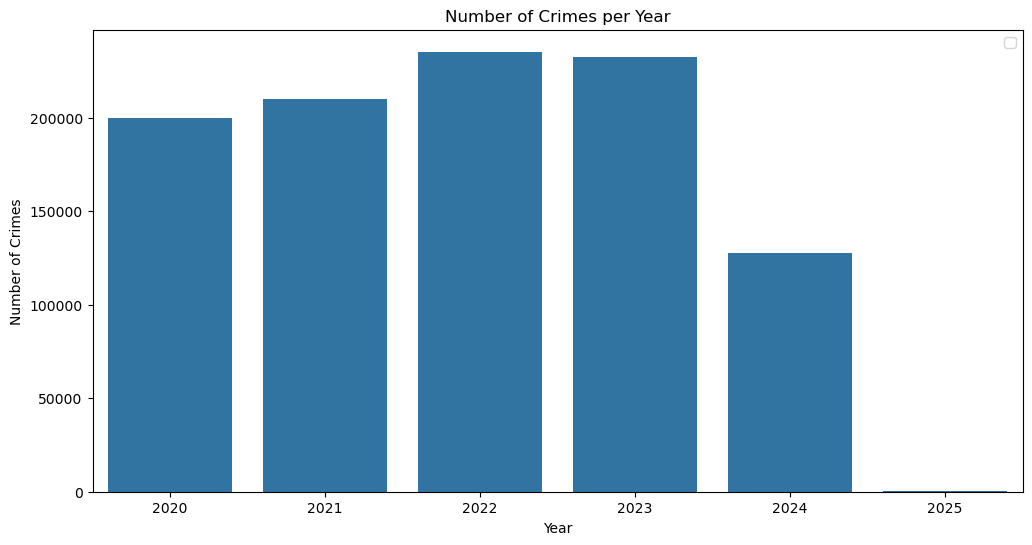

In [93]:
# Create the bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x=crime_counts_by_year.index, y=crime_counts_by_year.values)
plt.xlabel('Year')
plt.ylabel('Number of Crimes')
plt.title('Number of Crimes per Year')
plt.legend()
plt.show()





C:\Users\jeena\AppData\Local\Temp\ipykernel_21072\337245257.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=crime_counts_by_year.index, y=crime_counts_by_year.values, palette=colors)


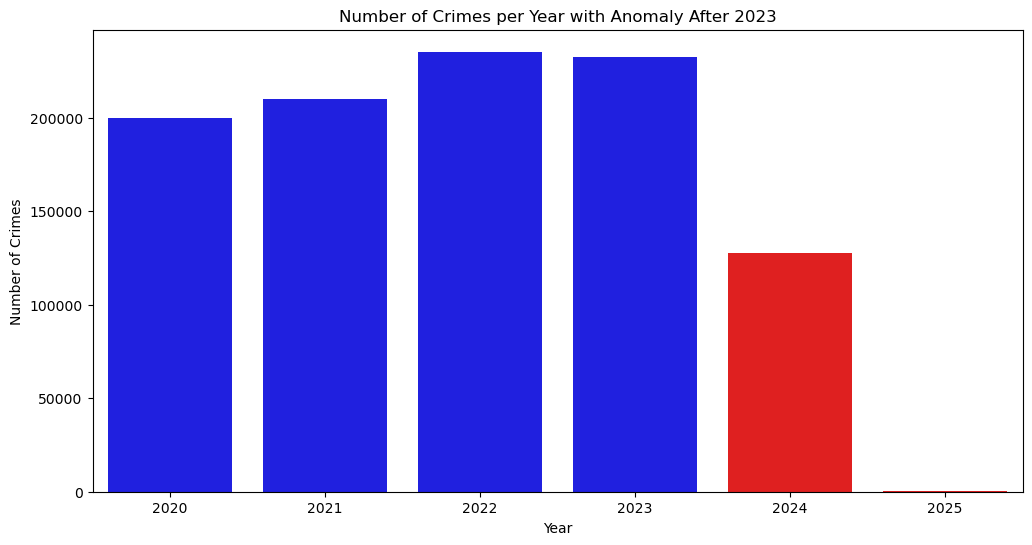

In [94]:
# Create the bar plot
plt.figure(figsize=(12, 6))

# Determine colors: Red for years after 2023, default for others
colors = ['red' if year > 2023 else 'blue' for year in crime_counts_by_year.index]
# Plot the bars
sns.barplot(x=crime_counts_by_year.index, y=crime_counts_by_year.values, palette=colors)
plt.xlabel('Year')
plt.ylabel('Number of Crimes')
plt.title('Number of Crimes per Year with Anomaly After 2023')
plt.show()

In [95]:
data = data[data['Year'] <= 2023]


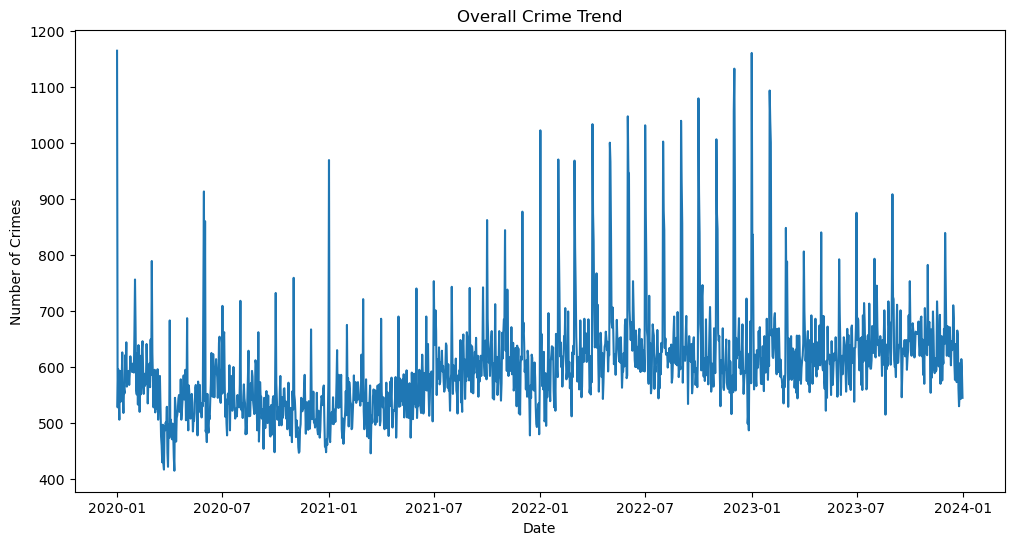

In [96]:
# Count the number of crimes by date
crime_counts = data.groupby('DATE OCC').size()

# Create the time series plot
plt.figure(figsize=(12, 6))
sns.lineplot(x=crime_counts.index, y=crime_counts.values)
plt.xlabel('Date')
plt.ylabel('Number of Crimes')
plt.title('Overall Crime Trend')
plt.show()

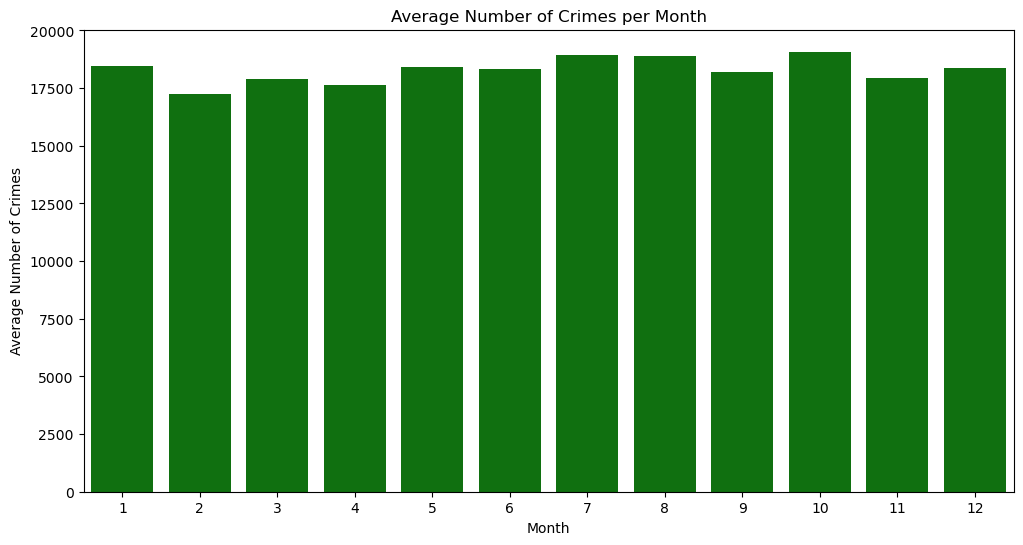

In [97]:
# Extract month from 'DATE OCC'
data['Month'] = data['DATE OCC'].dt.month

# Count the number of crimes for each month
monthly_crimes = data.groupby('Month').size()

# Calculate the average number of crimes per month
average_crimes_per_month = monthly_crimes / data['Year'].nunique()

# Create the bar plot for average monthly crime counts
plt.figure(figsize=(12, 6))
sns.barplot(x=average_crimes_per_month.index, y=average_crimes_per_month.values,color='green')
plt.xlabel('Month')
plt.ylabel('Average Number of Crimes')
plt.title('Average Number of Crimes per Month')
plt.show()

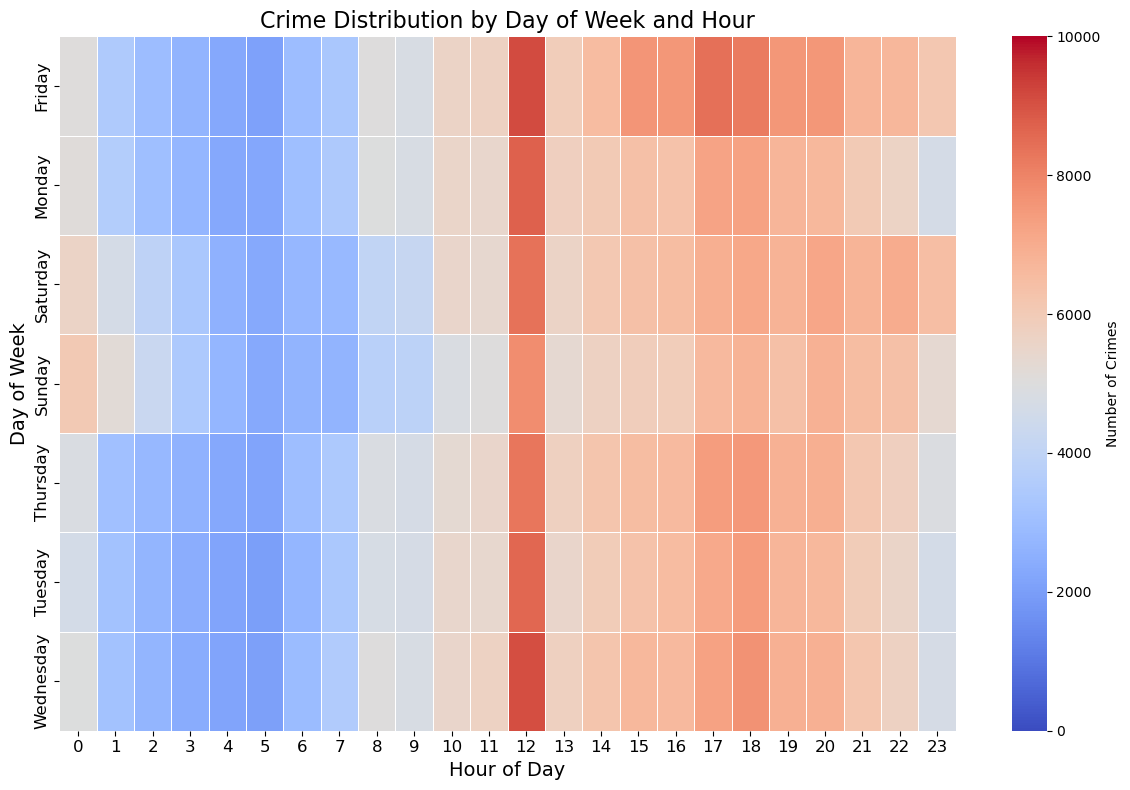

In [98]:

data['TIME OCC'] = data['TIME OCC'].astype(str).str.zfill(4)  # Ensure 4 digits for time

# Extract the hour from 'TIME OCC' column (first two digits represent the hour)
data['Hour'] = data['TIME OCC'].str[:2].astype(int)

# Extract day of the week from 'DATE OCC' and map to day names
data['DayOfWeek'] = data['DATE OCC'].dt.dayofweek
day_of_week_map = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
data['DayOfWeek'] = data['DayOfWeek'].map(day_of_week_map)

# Create a pivot table of crimes by Day of Week and Hour
crime_heatmap_data = data.pivot_table(index='DayOfWeek', columns='Hour', values='DATE OCC', aggfunc='count')

# Set vmax and vmin to scale colors based on the crimes data
# We are setting the maximum to be multiples of 1000 (to increase contrast every 1000 crimes)
max_crimes = crime_heatmap_data.values.max()
vmax = (max_crimes // 1000 + 1) * 1000  # Round up to the nearest 1000
vmin = 0  # Starting at 0 for minimum value

# Create the heatmap with adjusted contrast
plt.figure(figsize=(12, 8))  # Adjust figure size for better readability
sns.heatmap(crime_heatmap_data, cmap="coolwarm", annot=False, cbar_kws={'label': 'Number of Crimes'},
            linewidths=0.5, vmax=vmax, vmin=vmin)

# Improve the labels and title
plt.xlabel('Hour of Day', fontsize=14)
plt.ylabel('Day of Week', fontsize=14)
plt.title('Crime Distribution by Day of Week and Hour', fontsize=16)
plt.xticks(fontsize=12)  # Adjust x-axis font size
plt.yticks(fontsize=12)  # Adjust y-axis font size
plt.tight_layout()  # Adjust layout to fit labels properly

plt.show()


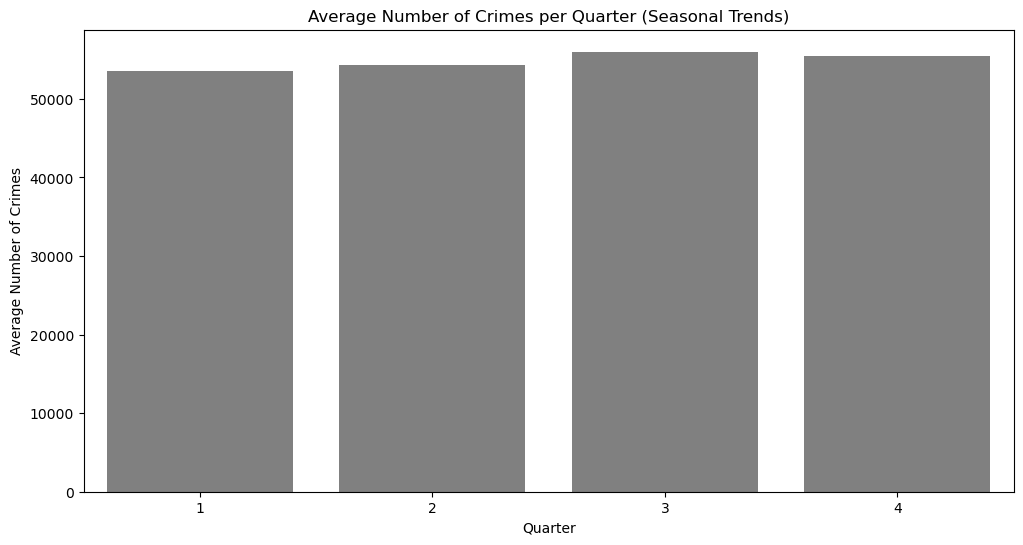

In [99]:
data['Quarter'] = data['DATE OCC'].dt.quarter

# Calculate the average number of crimes per quarter
average_crimes_by_quarter = data.groupby('Quarter').size() / data['Year'].nunique()

# Create the bar plot for average quarterly crime counts
plt.figure(figsize=(12, 6))
sns.barplot(x=average_crimes_by_quarter.index, y=average_crimes_by_quarter.values,color='grey')
plt.xlabel('Quarter')
plt.ylabel('Average Number of Crimes')
plt.title('Average Number of Crimes per Quarter (Seasonal Trends)')
plt.show()

C:\Users\jeena\AppData\Local\Temp\ipykernel_21072\1013043329.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Weekend', y='DATE OCC', data=data, inner="quart", palette="muted")


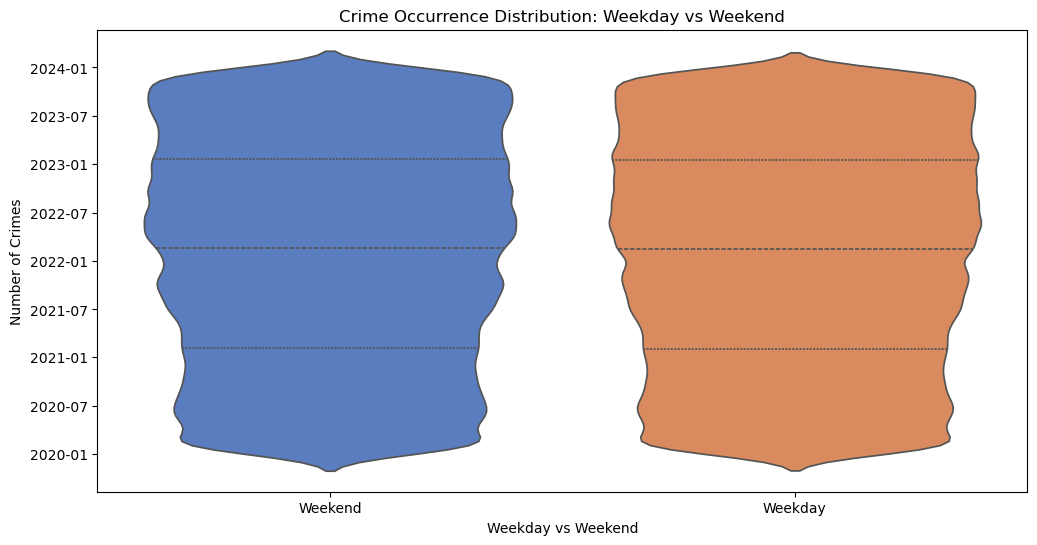

In [100]:
data['Weekend'] = data['DATE OCC'].dt.weekday.apply(lambda x: 'Weekend' if x in [4,5, 6] else 'Weekday')

# Create the violin plot for weekday vs weekend crimes
plt.figure(figsize=(12, 6))
sns.violinplot(x='Weekend', y='DATE OCC', data=data, inner="quart", palette="muted")
plt.xlabel('Weekday vs Weekend')
plt.ylabel('Number of Crimes')
plt.title('Crime Occurrence Distribution: Weekday vs Weekend')
plt.show()

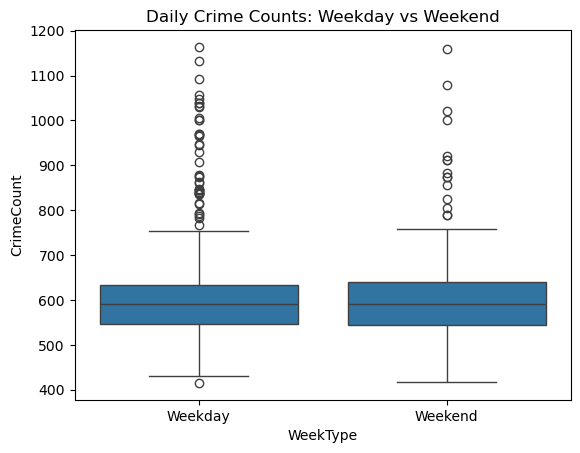

In [101]:
data['Date'] = pd.to_datetime(data['DATE OCC'])  # replace with your actual date column

# Step 2: Create a Weekday/Weekend column
data['DayOfWeek'] = data['Date'].dt.dayofweek
data['WeekType'] = data['DayOfWeek'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

# Step 3: Aggregate daily crime counts
daily_crimes = data.groupby(['Date', 'WeekType']).size().reset_index(name='CrimeCount')

# Step 4: Separate the two groups
weekend = daily_crimes[daily_crimes['WeekType'] == 'Weekend']['CrimeCount']
weekday = daily_crimes[daily_crimes['WeekType'] == 'Weekday']['CrimeCount']

sns.boxplot(data=daily_crimes, x='WeekType', y='CrimeCount')
plt.title('Daily Crime Counts: Weekday vs Weekend')
plt.show()

In [102]:
# Shapiro-Wilk Test for normality
print("Shapiro-Wilk test:")
print("Weekday:", stats.shapiro(weekday))
print("Weekend:", stats.shapiro(weekend))


Shapiro-Wilk test:
Weekday: ShapiroResult(statistic=0.8327911021027891, pvalue=1.1363279217161113e-31)
Weekend: ShapiroResult(statistic=0.8659046102128054, pvalue=1.6868128217386967e-18)


**Shapiro-Wilk p-value < 0.05:** This indicates that the data is not normally distributed. Both the Weekday and Weekend groups have p-values much smaller than 0.05, suggesting that both groups are significantly non-normal.

In [103]:
mw_test = stats.mannwhitneyu(weekday, weekend, alternative='two-sided')
print("Mann-Whitney U test result:", mw_test)

Mann-Whitney U test result: MannwhitneyuResult(statistic=217962.0, pvalue=0.9973177565376665)


**Based on the Mann-Whitney U test, we can conclude that there is no significant difference in the distribution of crime occurrences between weekdays and weekends. The p-value is so large that we don't have enough evidence to support a difference between the two groups.**

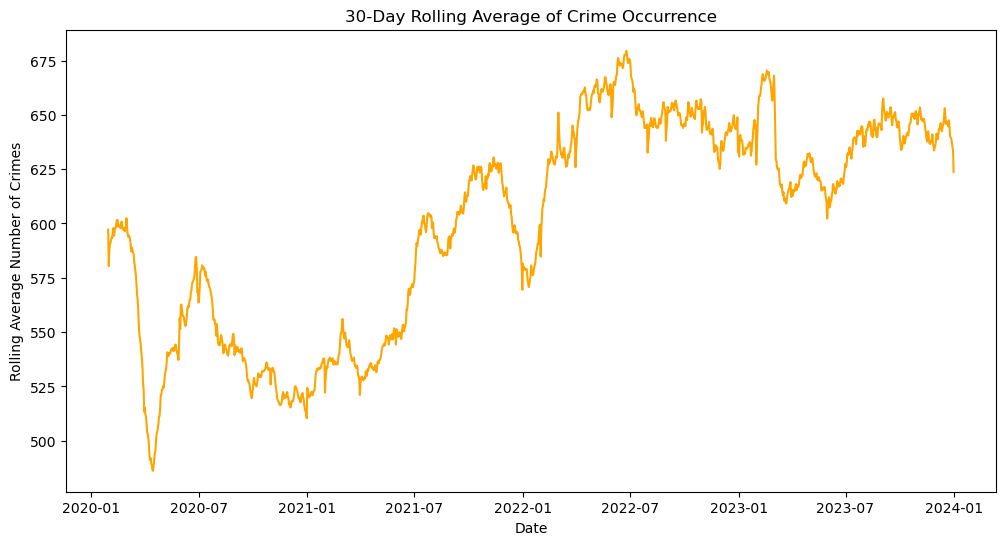

In [104]:
crime_counts_rolling_avg = crime_counts.rolling(window=30).mean()

# Create the rolling average line plot
plt.figure(figsize=(12, 6))
sns.lineplot(x=crime_counts_rolling_avg.index, y=crime_counts_rolling_avg.values, color='orange')
plt.xlabel('Date')
plt.ylabel('Rolling Average Number of Crimes')
plt.title('30-Day Rolling Average of Crime Occurrence')
plt.show()

In [105]:
crime_category_map = {
    # VIOLENT CRIMES
    'ARSON': 'VIOLENT CRIMES',
    'ASSAULT WITH DEADLY WEAPON ON POLICE OFFICER': 'VIOLENT CRIMES',
    'ASSAULT WITH DEADLY WEAPON': 'VIOLENT CRIMES',
    'AGGRAVATED ASSAULT': 'VIOLENT CRIMES',
    'ATTEMPTED ROBBERY': 'VIOLENT CRIMES',
    'BATTERY - SIMPLE ASSAULT': 'VIOLENT CRIMES',
    'BATTERY ON A FIREFIGHTER': 'VIOLENT CRIMES',
    'BATTERY POLICE (SIMPLE)': 'VIOLENT CRIMES',
    'BRANDISH WEAPON': 'VIOLENT CRIMES',
    'CRIMINAL HOMICIDE': 'VIOLENT CRIMES',
    'CRIMINAL THREATS - NO WEAPON DISPLAYED': 'VIOLENT CRIMES',
    'DISCHARGE FIREARMS/SHOTS FIRED': 'VIOLENT CRIMES',
    'DRUNK ROLL': 'VIOLENT CRIMES',
    'EXTORTION': 'VIOLENT CRIMES',
    'FALSE IMPRISONMENT': 'VIOLENT CRIMES',
    'HUMAN TRAFFICKING - COMMERCIAL SEX ACTS': 'VIOLENT CRIMES', # Broadly categorized as violent exploitation
    'HUMAN TRAFFICKING - INVOLUNTARY SERVITUDE': 'VIOLENT CRIMES',
    'INTIMATE PARTNER - AGGRAVATED ASSAULT': 'VIOLENT CRIMES',
    'INTIMATE PARTNER - SIMPLE ASSAULT': 'VIOLENT CRIMES',
    'KIDNAPPING': 'VIOLENT CRIMES',
    'KIDNAPPING - GRAND ATTEMPT': 'VIOLENT CRIMES',
    'LYNCHING': 'VIOLENT CRIMES',
    'LYNCHING - ATTEMPTED': 'VIOLENT CRIMES',
    'MANSLAUGHTER, NEGLIGENT': 'VIOLENT CRIMES',
    'OTHER ASSAULT': 'VIOLENT CRIMES',
    'ROBBERY': 'VIOLENT CRIMES',
    'SHOTS FIRED AT INHABITED DWELLING': 'VIOLENT CRIMES',
    'SHOTS FIRED AT MOVING VEHICLE, TRAIN OR AIRCRAFT': 'VIOLENT CRIMES',
    'STALKING': 'VIOLENT CRIMES',
    'THREATENING PHONE CALLS/LETTERS': 'VIOLENT CRIMES',
    'THROWING OBJECT AT MOVING VEHICLE': 'VIOLENT CRIMES',
    'WEAPONS POSSESSION/BOMBING': 'VIOLENT CRIMES', # Possession leading to potential violence

    # PROPERTY CRIMES
    'BIKE - ATTEMPTED STOLEN': 'PROPERTY CRIMES',
    'BIKE - STOLEN': 'PROPERTY CRIMES',
    'BOAT - STOLEN': 'PROPERTY CRIMES',
    'BURGLARY': 'PROPERTY CRIMES',
    'BURGLARY FROM VEHICLE': 'PROPERTY CRIMES',
    'BURGLARY FROM VEHICLE, ATTEMPTED': 'PROPERTY CRIMES',
    'BURGLARY, ATTEMPTED': 'PROPERTY CRIMES',
    'DEFRAUDING INNKEEPER/THEFT OF SERVICES, $950 & UNDER': 'PROPERTY CRIMES', # More theft than fraud here
    'DEFRAUDING INNKEEPER/THEFT OF SERVICES, OVER $950.01': 'PROPERTY CRIMES', # More theft than fraud here
    'DISHONEST EMPLOYEE - GRAND THEFT': 'PROPERTY CRIMES',
    'DISHONEST EMPLOYEE - PETTY THEFT': 'PROPERTY CRIMES',
    'DISHONEST EMPLOYEE ATTEMPTED THEFT': 'PROPERTY CRIMES',
    'DRIVING WITHOUT OWNER CONSENT (DWOC)': 'PROPERTY CRIMES',
    'GRAND THEFT / AUTO REPAIR': 'PROPERTY CRIMES', # Primarily theft aspect
    'PETTY THEFT - AUTO REPAIR': 'PROPERTY CRIMES', # Primarily theft aspect
    'PICKPOCKET': 'PROPERTY CRIMES',
    'PICKPOCKET, ATTEMPT': 'PROPERTY CRIMES',
    'PURSE SNATCHING': 'PROPERTY CRIMES',
    'PURSE SNATCHING - ATTEMPT': 'PROPERTY CRIMES',
    'SHOPLIFTING - ATTEMPT': 'PROPERTY CRIMES',
    'SHOPLIFTING - PETTY THEFT ($950 & UNDER)': 'PROPERTY CRIMES',
    'SHOPLIFTING-GRAND THEFT ($950.01 & OVER)': 'PROPERTY CRIMES',
    'TELEPHONE PROPERTY - DAMAGE': 'PROPERTY CRIMES',
    'THEFT FROM MOTOR VEHICLE - ATTEMPT': 'PROPERTY CRIMES',
    'THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND OVER)': 'PROPERTY CRIMES',
    'THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER)': 'PROPERTY CRIMES',
    'THEFT FROM PERSON - ATTEMPT': 'PROPERTY CRIMES',
    'THEFT PLAIN - ATTEMPT': 'PROPERTY CRIMES',
    'THEFT PLAIN - PETTY ($950 & UNDER)': 'PROPERTY CRIMES',
    'THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LIVESTK,PROD': 'PROPERTY CRIMES',
    'THEFT, COIN MACHINE - ATTEMPT': 'PROPERTY CRIMES',
    'THEFT, COIN MACHINE - GRAND ($950.01 & OVER)': 'PROPERTY CRIMES',
    'THEFT, COIN MACHINE - PETTY ($950 & UNDER)': 'PROPERTY CRIMES',
    'THEFT, PERSON': 'PROPERTY CRIMES',
    'TILL TAP - GRAND THEFT ($950.01 & OVER)': 'PROPERTY CRIMES',
    'TILL TAP - PETTY ($950 & UNDER)': 'PROPERTY CRIMES',
    'TRESPASSING': 'PROPERTY CRIMES',
    'VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)': 'PROPERTY CRIMES',
    'VANDALISM - MISDEAMEANOR ($399 OR UNDER)': 'PROPERTY CRIMES',
    'VEHICLE - ATTEMPT STOLEN': 'PROPERTY CRIMES',
    'VEHICLE - STOLEN': 'PROPERTY CRIMES',
    'VEHICLE, STOLEN - OTHER (MOTORIZED SCOOTERS, BIKES, ETC)': 'PROPERTY CRIMES',

    # SEX CRIMES
    'BATTERY WITH SEXUAL CONTACT': 'SEX CRIMES',
    'BEASTIALITY, CRIME AGAINST NATURE SEXUAL ASSLT WITH ANIM': 'SEX CRIMES',
    'INDECENT EXPOSURE': 'SEX CRIMES',
    'LEWD CONDUCT': 'SEX CRIMES',
    'ORAL COPULATION': 'SEX CRIMES',
    'PANDERING': 'SEX CRIMES',
    'PEEPING TOM': 'SEX CRIMES',
    'PIMPING': 'SEX CRIMES',
    'RAPE, ATTEMPTED': 'SEX CRIMES',
    'RAPE, FORCIBLE': 'SEX CRIMES',
    'SEX OFFENDER REGISTRANT OUT OF COMPLIANCE': 'SEX CRIMES', # Related to regulation of sex offenses
    'SEX,UNLAWFUL(INC MUTUAL CONSENT, PENETRATION W/ FRGN OBJ)': 'SEX CRIMES',
    'SEXUAL PENETRATION W/FOREIGN OBJECT': 'SEX CRIMES',
    'SODOMY/SEXUAL CONTACT B/W PENIS OF ONE PERS TO ANUS OTH': 'SEX CRIMES',

    # CRIMES AGAINST CHILDREN
    'CHILD ABANDONMENT': 'CRIMES AGAINST CHILDREN',
    'CHILD ABUSE (PHYSICAL) - AGGRAVATED ASSAULT': 'CRIMES AGAINST CHILDREN',
    'CHILD ABUSE (PHYSICAL) - SIMPLE ASSAULT': 'CRIMES AGAINST CHILDREN',
    'CHILD ANNOYING (17YRS & UNDER)': 'CRIMES AGAINST CHILDREN',
    'CHILD NEGLECT (SEE 300 W.I.C.)': 'CRIMES AGAINST CHILDREN',
    'CHILD PORNOGRAPHY': 'CRIMES AGAINST CHILDREN',
    'CHILD STEALING': 'CRIMES AGAINST CHILDREN',
    'CONTRIBUTING': 'CRIMES AGAINST CHILDREN', # Assuming contributing to delinquency of a minor
    'CRM AGNST CHLD (13 OR UNDER) (14-15 & SUSP 10 YRS OLDER)': 'CRIMES AGAINST CHILDREN',
    'DRUGS, TO A MINOR': 'CRIMES AGAINST CHILDREN',
    'INCEST (SEXUAL ACTS BETWEEN BLOOD RELATIVES)': 'CRIMES AGAINST CHILDREN', # Often involves minors or power imbalance
    'LEWD/LASCIVIOUS ACTS WITH CHILD': 'CRIMES AGAINST CHILDREN',
    'LETTERS, LEWD - TELEPHONE CALLS, LEWD': 'CRIMES AGAINST CHILDREN', # Often target minors or part of harassment

    # FRAUD & FINANCIAL CRIMES
    'BUNCO, ATTEMPT': 'FRAUD & FINANCIAL CRIMES',
    'BUNCO, GRAND THEFT': 'FRAUD & FINANCIAL CRIMES',
    'BUNCO, PETTY THEFT': 'FRAUD & FINANCIAL CRIMES',
    'COUNTERFEIT': 'FRAUD & FINANCIAL CRIMES',
    'CREDIT CARDS, FRAUD USE ($950 & UNDER': 'FRAUD & FINANCIAL CRIMES',
    'CREDIT CARDS, FRAUD USE ($950.01 & OVER)': 'FRAUD & FINANCIAL CRIMES',
    'DOCUMENT FORGERY / STOLEN FELONY': 'FRAUD & FINANCIAL CRIMES',
    'DOCUMENT WORTHLESS ($200 & UNDER)': 'FRAUD & FINANCIAL CRIMES',
    'DOCUMENT WORTHLESS ($200.01 & OVER)': 'FRAUD & FINANCIAL CRIMES',
    'EMBEZZLEMENT, GRAND THEFT ($950.01 & OVER)': 'FRAUD & FINANCIAL CRIMES',
    'EMBEZZLEMENT, PETTY THEFT ($950 & UNDER)': 'FRAUD & FINANCIAL CRIMES',
    'GRAND THEFT / INSURANCE FRAUD': 'FRAUD & FINANCIAL CRIMES',
    'THEFT OF IDENTITY': 'FRAUD & FINANCIAL CRIMES',
    'UNAUTHORIZED COMPUTER ACCESS': 'FRAUD & FINANCIAL CRIMES', # Often related to financial/data theft

    # CRIMES AGAINST PUBLIC ORDER & SAFETY
    'BIGAMY': 'CRIMES AGAINST PUBLIC ORDER & SAFETY', # Affects public record/order
    'BLOCKING DOOR INDUCTION CENTER': 'CRIMES AGAINST PUBLIC ORDER & SAFETY',
    'BOMB SCARE': 'CRIMES AGAINST PUBLIC ORDER & SAFETY',
    'CRUELTY TO ANIMALS': 'CRIMES AGAINST PUBLIC ORDER & SAFETY',
    'DISRUPT SCHOOL': 'CRIMES AGAINST PUBLIC ORDER & SAFETY',
    'DISTURBING THE PEACE': 'CRIMES AGAINST PUBLIC ORDER & SAFETY',
    'FAILURE TO DISPERSE': 'CRIMES AGAINST PUBLIC ORDER & SAFETY',
    'FAILURE TO YIELD': 'CRIMES AGAINST PUBLIC ORDER & SAFETY',
    'ILLEGAL DUMPING': 'CRIMES AGAINST PUBLIC ORDER & SAFETY',
    'INCITING A RIOT': 'CRIMES AGAINST PUBLIC ORDER & SAFETY',
    'OTHER MISCELLANEOUS CRIME': 'CRIMES AGAINST PUBLIC ORDER & SAFETY', # Default bucket
    'PROWLER': 'CRIMES AGAINST PUBLIC ORDER & SAFETY',
    'RECKLESS DRIVING': 'CRIMES AGAINST PUBLIC ORDER & SAFETY',
    'REPLICA FIREARMS(SALE,DISPLAY,MANUFACTURE OR DISTRIBUTE)': 'CRIMES AGAINST PUBLIC ORDER & SAFETY',

    # CRIMES AGAINST JUSTICE & GOVERNMENT
    'BRIBERY': 'CRIMES AGAINST JUSTICE & GOVERNMENT',
    'CONSPIRACY': 'CRIMES AGAINST JUSTICE & GOVERNMENT', # Often conspiracy to commit other crimes, but fundamentally against legal order
    'CONTEMPT OF COURT': 'CRIMES AGAINST JUSTICE & GOVERNMENT',
    'FALSE POLICE REPORT': 'CRIMES AGAINST JUSTICE & GOVERNMENT',
    'FIREARMS EMERGENCY PROTECTIVE ORDER (FIREARMS EPO)': 'CRIMES AGAINST JUSTICE & GOVERNMENT', # Violation of order
    'FIREARMS RESTRAINING ORDER (FIREARMS RO)': 'CRIMES AGAINST JUSTICE & GOVERNMENT', # Violation of order
    'RESISTING ARREST': 'CRIMES AGAINST JUSTICE & GOVERNMENT',
    'VIOLATION OF COURT ORDER': 'CRIMES AGAINST JUSTICE & GOVERNMENT',
    'VIOLATION OF RESTRAINING ORDER': 'CRIMES AGAINST JUSTICE & GOVERNMENT',
    'VIOLATION OF TEMPORARY RESTRAINING ORDER': 'CRIMES AGAINST JUSTICE & GOVERNMENT',
}

# 2. Apply the mapping to the 'Crm Cd Desc' column to create a new column
data['Crime Category'] = data['Crm Cd Desc'].map(crime_category_map)
# Step 3: Check the distribution of crimes across the new categories
print(data['Crime Category'].value_counts())



Crime Category
PROPERTY CRIMES                         480843
VIOLENT CRIMES                          212450
FRAUD & FINANCIAL CRIMES                 71970
CRIMES AGAINST JUSTICE & GOVERNMENT      21484
SEX CRIMES                               13483
CRIMES AGAINST PUBLIC ORDER & SAFETY     10317
CRIMES AGAINST CHILDREN                   8468
Name: count, dtype: int64


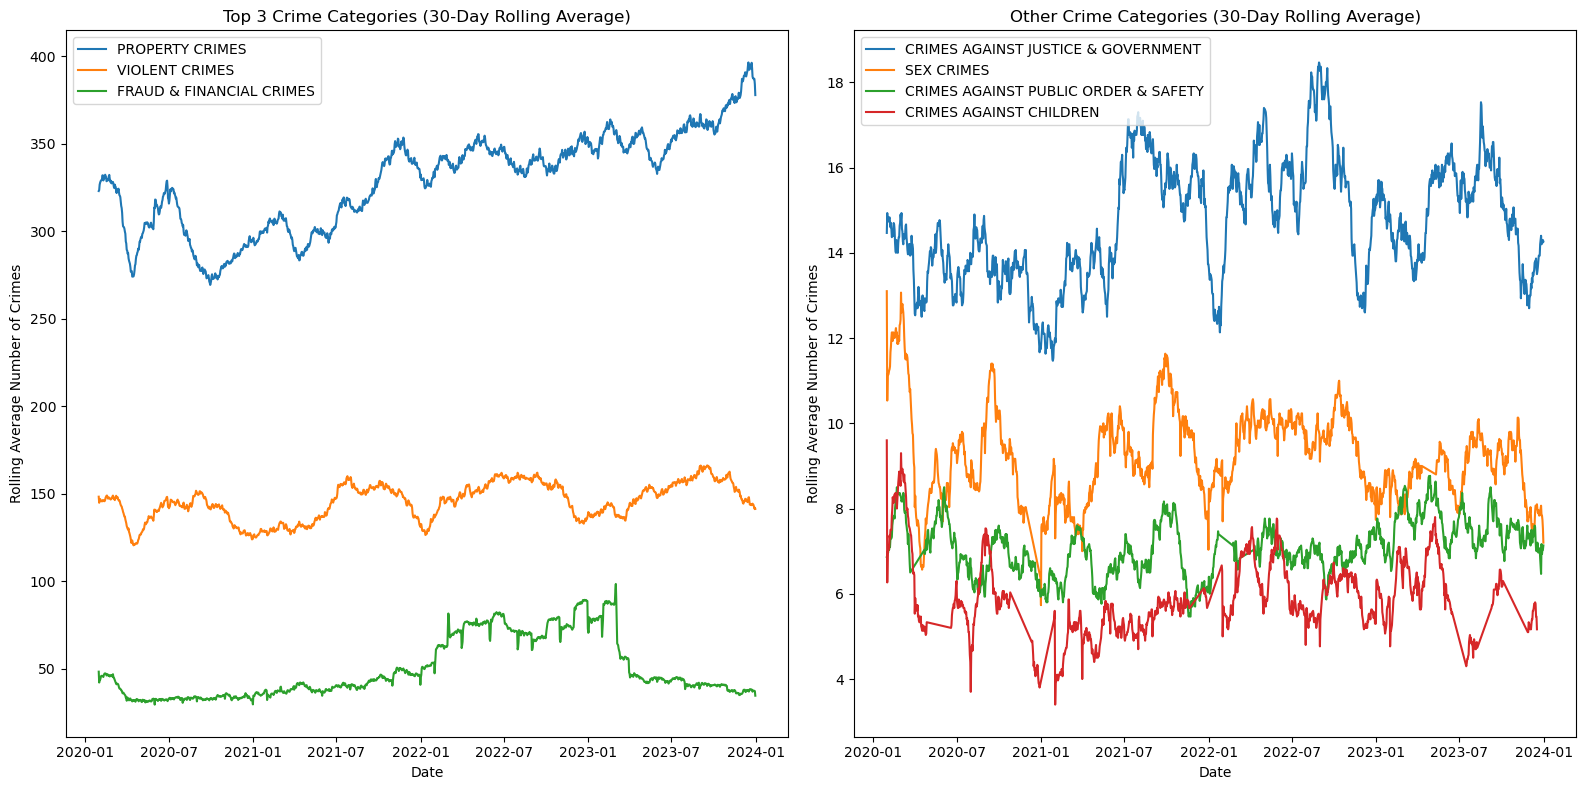

In [106]:
crime_counts = data.groupby(['Date', 'Crime Category']).size().reset_index(name='Crime Count')
crime_counts_pivot = crime_counts.pivot(index='Date', columns='Crime Category', values='Crime Count')
crime_counts_rolling_avg = crime_counts_pivot.rolling(window=30).mean()


top_crimes = crime_counts_rolling_avg.sum().sort_values(ascending=False).head(3).index
other_crimes = crime_counts_rolling_avg.sum().sort_values(ascending=False).tail(4).index

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for column in top_crimes:
    sns.lineplot(x=crime_counts_rolling_avg.index, y=crime_counts_rolling_avg[column], ax=axes[0], label=column)

axes[0].set_title('Top 3 Crime Categories (30-Day Rolling Average)')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Rolling Average Number of Crimes')
axes[0].legend()

for column in other_crimes:
    sns.lineplot(x=crime_counts_rolling_avg.index, y=crime_counts_rolling_avg[column], ax=axes[1], label=column)

axes[1].set_title('Other Crime Categories (30-Day Rolling Average)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Rolling Average Number of Crimes')
axes[1].legend()

plt.tight_layout()
plt.show()


### Demoraphic deep-dive

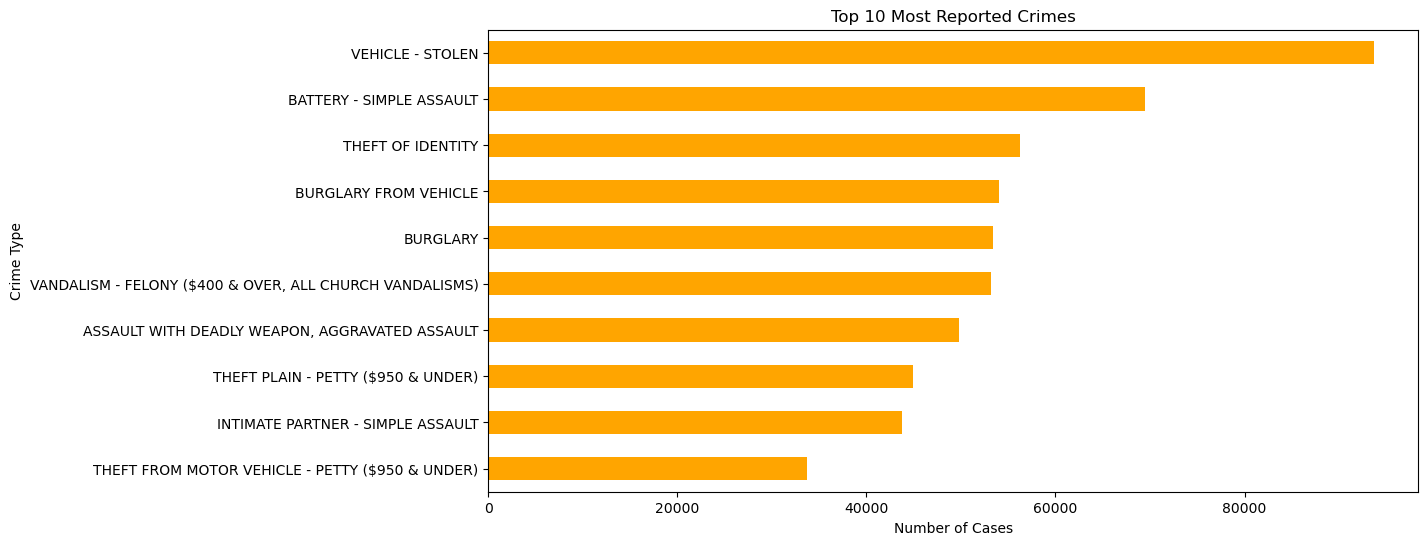

In [107]:
plt.figure(figsize=(12, 6))
data["Crm Cd Desc"].value_counts().nlargest(10).sort_values().plot(kind="barh", color="orange")
plt.title("Top 10 Most Reported Crimes")
plt.xlabel("Number of Cases")
plt.ylabel("Crime Type")
plt.show()

In [108]:
data['Vict Sex'].value_counts()

Vict Sex
M    360676
F    322438
X    194097
H        97
Name: count, dtype: int64

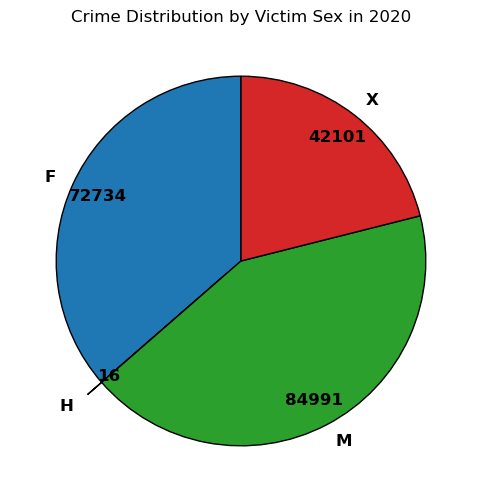

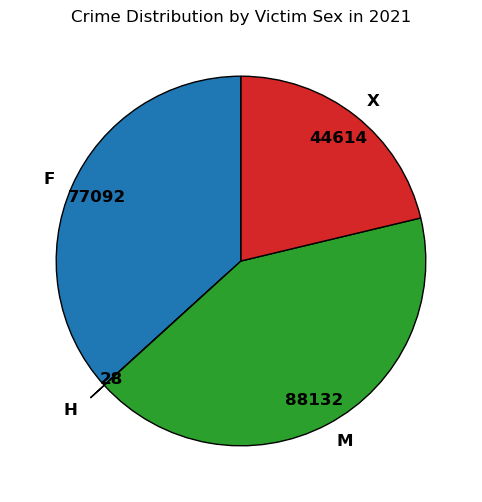

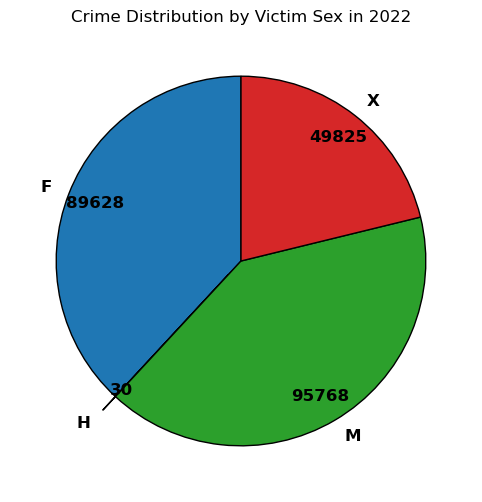

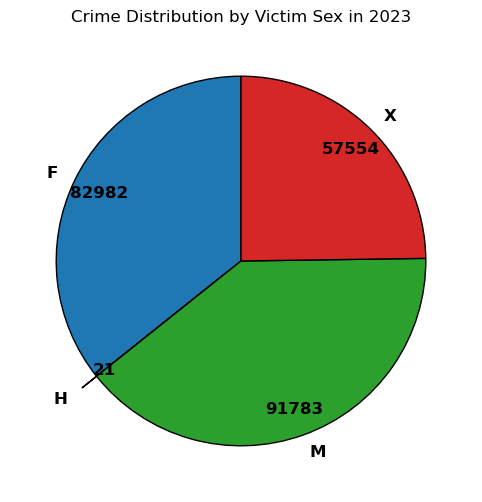

In [109]:
crime_by_year_sex = data.groupby(['Year', 'Vict Sex']).size().unstack(fill_value=0)

for year in crime_by_year_sex.index:
    plt.figure(figsize=(8, 6))  # Adjust figure size as needed
    plt.title(f'Crime Distribution by Victim Sex in {year}')

    # Get values for the specific year and drop NaN values
    values = crime_by_year_sex.loc[year].dropna()

    # Create explode list: explode smaller sections
    explode = [0.1 if value == min(values) else 0 for value in values]

    # Define the autopct function
    autopct_func = lambda pct, total: f'{int(pct * total / 100)}' if pct * total / 100 else '0'

    # Plot pie chart with absolute values and explode smaller sections
    values.plot.pie(
        autopct=lambda pct: autopct_func(pct, values.sum()),
        startangle=90,
        explode=explode,
        figsize=(8, 6),
        labels=values.index,
        wedgeprops={'edgecolor': 'black'},
        pctdistance=0.85,
        textprops={'fontsize': 12, 'weight': 'bold'}
    )

    plt.ylabel('')  # Hide the y-axis label
    plt.show()

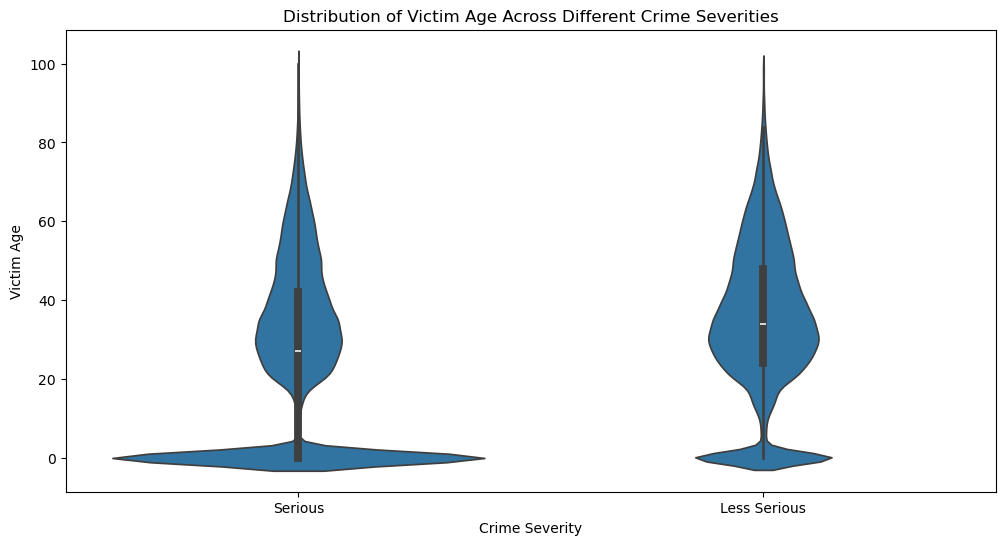

In [110]:
data['Crime Severity'] = data['Part 1-2'].map({1: 'Serious', 2: 'Less Serious'})

# Step 3: Visualize the relationship using a Violin Plot
plt.figure(figsize=(12, 6))
sns.violinplot(x='Crime Severity', y='Vict Age', data=data)
plt.title('Distribution of Victim Age Across Different Crime Severities')
plt.xlabel('Crime Severity')
plt.ylabel('Victim Age')
plt.show()



In [111]:
# Group data by 'Crime Severity'
serious_age_data = data[data['Crime Severity'] == 'Serious']['Vict Age']
less_serious_age_data = data[data['Crime Severity'] == 'Less Serious']['Vict Age']

# Perform Shapiro-Wilk test to check normality for both groups
serious_normality = stats.shapiro(serious_age_data)
less_serious_normality = stats.shapiro(less_serious_age_data)

print(f"Shapiro-Wilk Test for Serious Crime: p-value = {serious_normality[1]}")
print(f"Shapiro-Wilk Test for Less Serious Crime: p-value = {less_serious_normality[1]}")



Shapiro-Wilk Test for Serious Crime: p-value = 2.027789167719988e-144
Shapiro-Wilk Test for Less Serious Crime: p-value = 8.679937326039885e-100


c:\Users\jeena\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 514854.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\jeena\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 362454.
  res = hypotest_fun_out(*samples, **kwds)


In [112]:
# Perform Mann-Whitney U test (non-parametric test)
u_stat, p_val = stats.mannwhitneyu(serious_age_data, less_serious_age_data)
print(f"Mann-Whitney U Test Result: U-statistic = {u_stat}, p-value = {p_val}")

if p_val < 0.05:
  print("There is a significant difference in victim age between Serious and Less Serious crimes (p < 0.05).")
else:
  print("There is no significant difference in victim age between Serious and Less Serious crimes (p >= 0.05).")

Mann-Whitney U Test Result: U-statistic = 72300206277.0, p-value = 0.0
There is a significant difference in victim age between Serious and Less Serious crimes (p < 0.05).


In [113]:
pd.set_option('display.max_rows', None)
data['Crm Cd Desc'].value_counts()

Crm Cd Desc
VEHICLE - STOLEN                                            93673
BATTERY - SIMPLE ASSAULT                                    69421
THEFT OF IDENTITY                                           56216
BURGLARY FROM VEHICLE                                       53990
BURGLARY                                                    53411
VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)     53140
ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT              49828
THEFT PLAIN - PETTY ($950 & UNDER)                          44899
INTIMATE PARTNER - SIMPLE ASSAULT                           43716
THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER)             33698
THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND OVER)         31318
ROBBERY                                                     29813
THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LIVESTK,PROD    29145
VANDALISM - MISDEAMEANOR ($399 OR UNDER)                    22988
SHOPLIFTING - PETTY THEFT ($950 & UNDER)                    2185

<Figure size 1200x800 with 0 Axes>

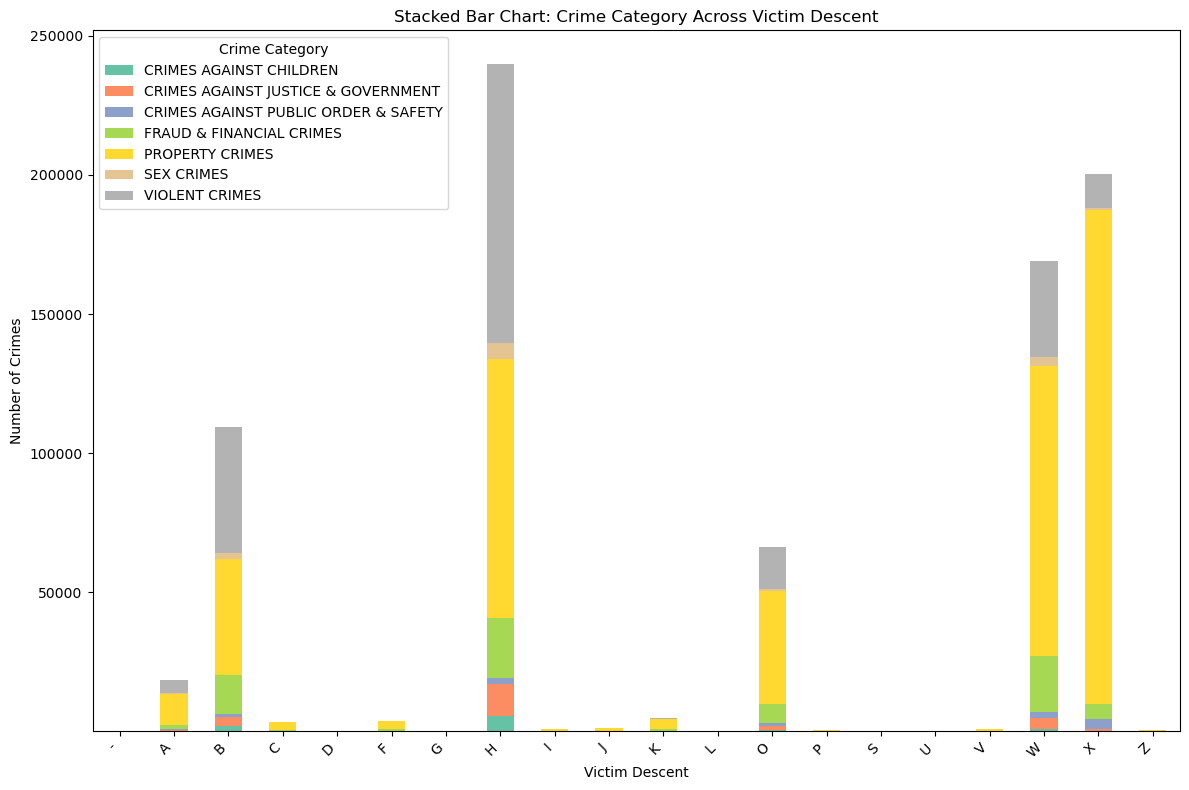

In [120]:
data = data.dropna(subset=['Vict Descent', 'Crime Category'])
data.drop_duplicates(inplace=True)

# Step 2: Create a contingency table (cross-tabulation) of Victim Descent and Crime Category
contingency_table = pd.crosstab(data['Vict Descent'], data['Crime Category'])

# Step 3: Plot the Stacked Bar Chart
plt.figure(figsize=(12, 8))
contingency_table.plot(kind='bar', stacked=True, figsize=(12, 8), colormap="Set2")
plt.title('Stacked Bar Chart: Crime Category Across Victim Descent')
plt.xlabel('Victim Descent')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Crime Category')
plt.tight_layout()  # Adjust the layout to make room for labels
plt.show()


In [ ]:
def map_descent(desc):
    if desc == 'W':  # White
        return 'White'
    elif desc == 'B':  # Black
        return 'Black'
    elif desc == 'H':  # Hispanic/Latin/Mexican
        return 'Hispanic'
    elif desc in ['A', 'C', 'D', 'F', 'G', 'I', 'J', 'K', 'L', 'P', 'S', 'U', 'V', 'Z']:  # Asian-related descents
        return 'Asian'
    else:  # Everything else (including Unknown)
        return 'Other'

data['Simplified Vict Descent'] = data['Vict Descent'].apply(map_descent)
print(data['Simplified Vict Descent'].value_counts())


Simplified Vict Descent
Other       266568
Hispanic    240018
White       169090
Black       109214
Asian        34125
Name: count, dtype: int64


<Figure size 1200x800 with 0 Axes>

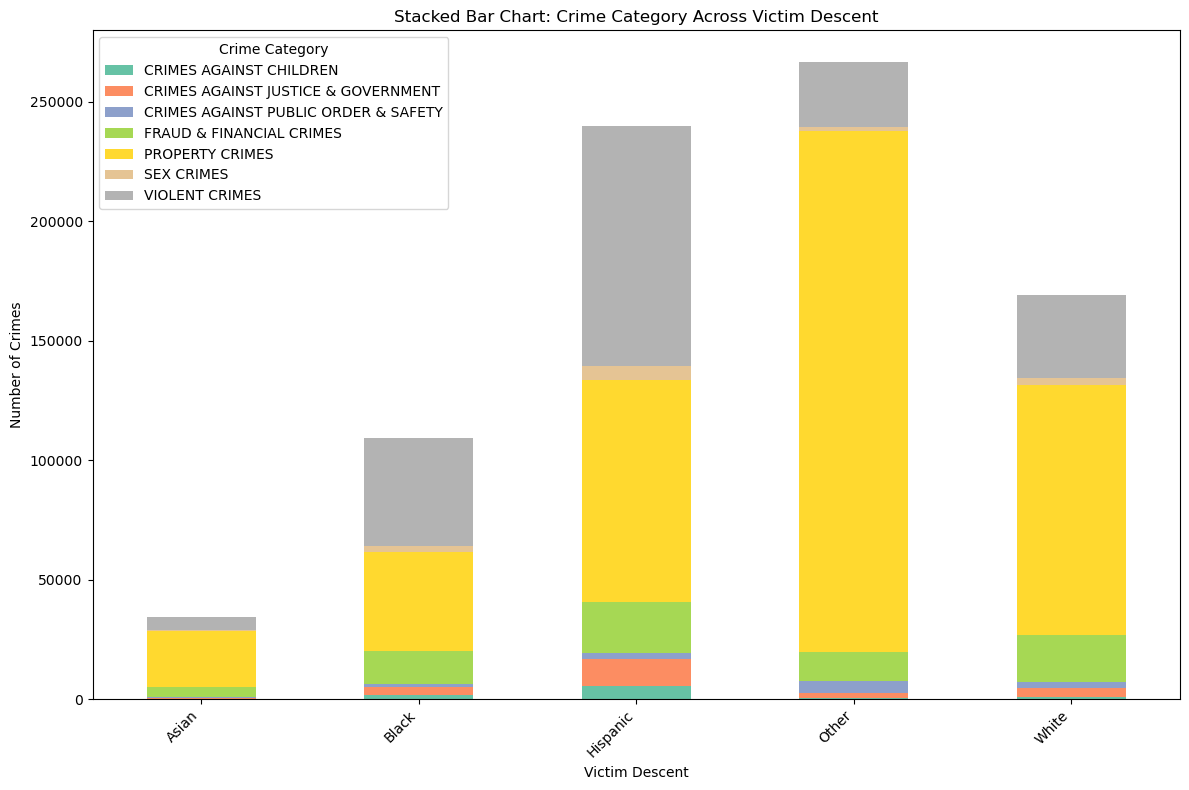

In [ ]:
contingency_table = pd.crosstab(data['Simplified Vict Descent'], data['Crime Category'])
data.drop_duplicates(inplace=True)

# Step 3: Plot the Stacked Bar Chart
plt.figure(figsize=(12, 8))
contingency_table.plot(kind='bar', stacked=True, figsize=(12, 8), colormap="Set2")
plt.title('Stacked Bar Chart: Crime Category Across Victim Descent')
plt.xlabel('Victim Descent')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Crime Category')
plt.tight_layout()  # Adjust the layout to make room for labels
plt.show()


In [ ]:
chi2_stat, p_val, dof, expected = stats.chi2_contingency(contingency_table)

# Step 3: Print the Chi-square test results
print(f"Chi-Square Statistic: {chi2_stat}")
print(f"Degrees of Freedom: {dof}")
print(f"Expected Frequencies Table: \n{expected}")
print(f"P-Value: {p_val}")

# Step 4: Interpretation of the p-value
if p_val < 0.05:
    print("There is a significant association between Victim Descent and Crime Category (p < 0.05).")
else:
    print("There is no significant association between Victim Descent and Crime Category (p >= 0.05).")

Chi-Square Statistic: 139365.95468782078
Degrees of Freedom: 24
Expected Frequencies Table: 
[[   352.8268713     895.15027197    429.86712698   2998.69507884
   20034.75806304    561.78137763   8851.92121023]
 [  1129.19073765   2864.84811145   1375.75116207   9597.05448618
   64119.44518965   1797.93088283  28329.77943017]
 [  2481.6058607    6296.03451951   3023.46807568  21091.30536071
  140914.3607553    3951.28623285  62259.93919525]
 [  2756.11292101   6992.48110474   3357.91414809  23424.35603744
  156501.8428527    4388.36449149  69146.92844453]
 [  1748.26360934   4435.48599232   2129.99948719  14858.58903683
   99272.59313932   2783.6370152   43861.43171981]]
P-Value: 0.0
There is a significant association between Victim Descent and Crime Category (p < 0.05).


In [ ]:
data.head()
data.drop_duplicates(inplace=True)


In [ ]:
!pip install holidays
import holidays
data['Date'] = pd.to_datetime(data['Date'])
# Step 1: Extract useful date features
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['DayOfWeek'] = data['Date'].dt.dayofweek
data.drop_duplicates(inplace=True)

# Step 2: Check for holidays (using the 'holidays' library for USA)
us_holidays = holidays.US(years=[2020,2021,2022,2023])  # Adjust years and countries as needed
data['IsHoliday'] = data['Date'].isin(us_holidays.keys())  # This will be a boolean column

data.head()

C:\Users\jeena\AppData\Local\Temp\ipykernel_21072\4278785463.py:12: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  data['IsHoliday'] = data['Date'].isin(us_holidays.keys())  # This will be a boolean column


,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Weapon Used Cd,Weapon Desc,Status,Status Desc,LOCATION,LAT,LON,Year,Month,Hour,DayOfWeek,Quarter,Weekend,Date,WeekType,Crime Category,Crime Severity,Simplified Vict Descent,IsHoliday
0,190326475,03/01/2020 12:00:00 AM,2020-03-01,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN,0344,0.0,M,O,101.0,STREET,Weapon Usage Not Known,Unknown,AA,Adult Arrest,1900 S LONGWOOD AV,34.0375,-118.3506,2020,3,21,6,1,Weekend,2020-03-01,Weekend,PROPERTY CRIMES,Serious,Other,False
1,200106753,02/09/2020 12:00:00 AM,2020-02-08,1800,1,Central,182,1,330,BURGLARY FROM VEHICLE,1822 1402 0344,47.0,M,O,128.0,BUS STOP/LAYOVER (ALSO QUERY 124),Weapon Usage Not Known,Unknown,IC,Invest Cont,1000 S FLOWER ST,34.0444,-118.2628,2020,2,18,5,1,Weekend,2020-02-08,Weekend,PROPERTY CRIMES,Serious,Other,False
2,200320258,11/11/2020 12:00:00 AM,2020-11-04,1700,3,Southwest,356,1,480,BIKE - STOLEN,0344 1251,19.0,X,X,502.0,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",Weapon Usage Not Known,Unknown,IC,Invest Cont,1400 W 37TH ST,34.0210,-118.3002,2020,11,17,2,4,Weekday,2020-11-04,Weekday,PROPERTY CRIMES,Serious,Other,False
3,200907217,05/10/2023 12:00:00 AM,2020-03-10,2037,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),0325 1501,19.0,M,O,405.0,CLOTHING STORE,Weapon Usage Not Known,Unknown,IC,Invest Cont,14000 RIVERSIDE DR,34.1576,-118.4387,2020,3,20,1,1,Weekday,2020-03-10,Weekday,PROPERTY CRIMES,Serious,Other,False
4,200412582,09/09/2020 12:00:00 AM,2020-09-09,0630,4,Hollenbeck,413,1,510,VEHICLE - STOLEN,0344,0.0,X,X,101.0,STREET,Weapon Usage Not Known,Unknown,IC,Invest Cont,200 E AVENUE 28,34.0820,-118.2130,2020,9,6,2,3,Weekday,2020-09-09,Weekday,PROPERTY CRIMES,Serious,Other,False


In [ ]:
data['IsWeekendorHoliday'] = (data['WeekType'] == 'Weekend') | (data['IsHoliday'] == True)
data.drop_duplicates(inplace=True)



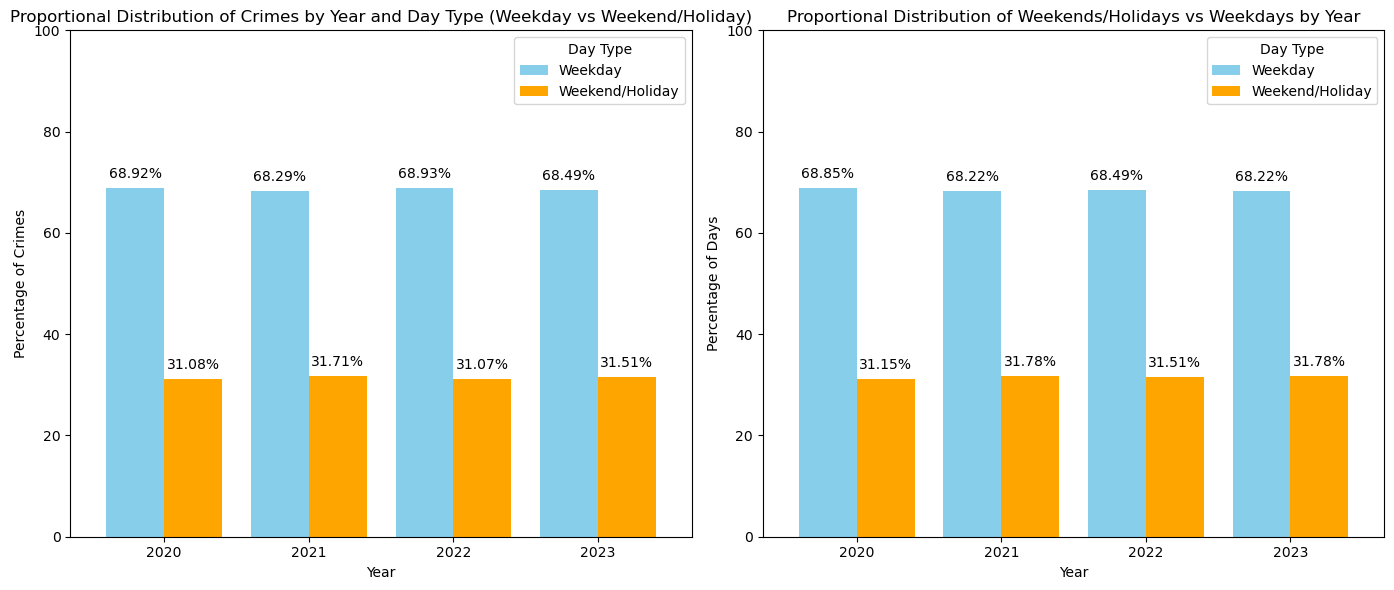

In [ ]:
crime_distribution_counts = data.groupby(['Year', 'IsWeekendorHoliday'])['IsWeekendorHoliday'].count().unstack()

# Calculate proportions for each group within each year (percentage of crimes)
crime_distribution_percentage = crime_distribution_counts.div(crime_distribution_counts.sum(axis=1), axis=0) * 100

# Create the figure and axis objects for side-by-side plotting (group bar charts)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot percentage of crimes by year and day type (grouped bar chart)
crime_distribution_percentage.plot(kind='bar', ax=ax1, color=['skyblue', 'orange'], width=0.8)
ax1.set_title('Proportional Distribution of Crimes by Year and Day Type (Weekday vs Weekend/Holiday)')
ax1.set_xlabel('Year')
ax1.set_ylabel('Percentage of Crimes')
ax1.legend(title='Day Type', labels=['Weekday', 'Weekend/Holiday'])
ax1.set_xticklabels(crime_distribution_percentage.index, rotation=0)
ax1.set_ylim(0, 100)  # Proportions should sum to 100%

# Annotate bars with percentage values for crimes
for p in ax1.patches:
    height = p.get_height()
    if height > 0:  # Add annotation only for non-zero values
        ax1.annotate(f'{height:.2f}%',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     xytext=(0, 10),  # 10 points vertical offset
                     textcoords='offset points',
                     ha='center', va='center', fontsize=10)

# Calculate distribution of holidays by year (weekends/holidays vs weekdays)
# Drop duplicates to ensure we only count one entry per day
holiday_distribution = data.drop_duplicates(subset=['Date'])

# Group by year and IsWeekendorHoliday, then calculate count
holiday_distribution = holiday_distribution.groupby(['Year', 'IsWeekendorHoliday']).size().unstack()
data.drop_duplicates(inplace=True)

# Calculate proportions for each group within each year (percentage of holidays)
holiday_distribution_percentage = holiday_distribution.div(holiday_distribution.sum(axis=1), axis=0) * 100

# Plot holiday distribution by year and day type (grouped bar chart)
holiday_distribution_percentage.plot(kind='bar', ax=ax2, color=['skyblue', 'orange'], width=0.8)
ax2.set_title('Proportional Distribution of Weekends/Holidays vs Weekdays by Year')
ax2.set_xlabel('Year')
ax2.set_ylabel('Percentage of Days')
ax2.legend(title='Day Type', labels=['Weekday', 'Weekend/Holiday'])
ax2.set_xticklabels(holiday_distribution_percentage.index, rotation=0)
ax2.set_ylim(0, 100)  # Proportions should sum to 100%
data.drop_duplicates(inplace=True)

# Annotate bars with percentage values for holidays
for p in ax2.patches:
    height = p.get_height()
    if height > 0:  # Add annotation only for non-zero values
        ax2.annotate(f'{height:.2f}%',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     xytext=(0, 10),  # 10 points vertical offset
                     textcoords='offset points',
                     ha='center', va='center', fontsize=10)
data.drop_duplicates(inplace=True)

# Adjust layout to make sure there is enough space between the plots
plt.tight_layout()
plt.show()

In [ ]:
weekend_or_holiday_data = data[data['IsWeekendorHoliday'] == True]
weekday_data = data[data['IsWeekendorHoliday'] == False]

# Step 1: Check if the number of crimes on weekdays and weekends/holidays follows a normal distribution
# Shapiro-Wilk test for normality
shapiro_weekday = stats.shapiro(weekday_data['Crm Cd'])  # Replace 'Crm Cd' with the appropriate column for crime counts
shapiro_weekend = stats.shapiro(weekend_or_holiday_data['Crm Cd'])  # Same here

print(f"Shapiro-Wilk Test for Weekday Crimes: {shapiro_weekday}")
print(f"Shapiro-Wilk Test for Weekend/Holiday Crimes: {shapiro_weekend}")





Shapiro-Wilk Test for Weekday Crimes: ShapiroResult(statistic=0.937551007418269, pvalue=2.3865504068455776e-131)
Shapiro-Wilk Test for Weekend/Holiday Crimes: ShapiroResult(statistic=0.9472168810539098, pvalue=2.017952534266365e-113)


c:\Users\jeena\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 562314.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\jeena\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 256701.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
# Data is not normally distributed, apply Mann-Whitney U test
mannwhitney_stat, mannwhitney_p = stats.mannwhitneyu(weekday_data['Crm Cd'], weekend_or_holiday_data['Crm Cd'])
print(f"Mann-Whitney U test results: U-statistic = {mannwhitney_stat}, p-value = {mannwhitney_p}")
if mannwhitney_p < 0.05:
    print("There is a significant difference in the number of crimes between weekdays and weekends/holidays (p < 0.05).")
else:
    print("There is no significant difference in the number of crimes between weekdays and weekends/holidays (p >= 0.05).")

Mann-Whitney U test results: U-statistic = 71635158203.0, p-value = 5.5700803698865494e-08
There is a significant difference in the number of crimes between weekdays and weekends/holidays (p < 0.05).


In [ ]:
data['AREA NAME']=data['AREA NAME'].str.upper()
data.head(5)
data.drop_duplicates(inplace=True)


In [ ]:
# Aggregating crime counts
# 1. By AREA
area_crime_counts = data.groupby('AREA NAME').size().reset_index(name='Crimes_by_Area')
data = pd.merge(data, area_crime_counts, on='AREA NAME', how='left')
data.drop_duplicates(inplace=True)

# 2. By AREA + Year
area_year_crime_counts = data.groupby(['AREA NAME', 'Year']).size().reset_index(name='Crimes_by_Area_Year')
data = pd.merge(data, area_year_crime_counts, on=['AREA NAME', 'Year'], how='left')
data.drop_duplicates(inplace=True)

# 3. By AREA + Year + Month
area_year_month_crime_counts = data.groupby(['AREA NAME', 'Year', 'Month']).size().reset_index(name='Crimes_by_Area_Year_Month')
data = pd.merge(data, area_year_month_crime_counts, on=['AREA NAME', 'Year', 'Month'], how='left')
data.drop_duplicates(inplace=True)

# 4. By AREA + Crime Category
area_category_crime_counts = data.groupby(['AREA NAME', 'Crime Category']).size().reset_index(name='Crimes_by_Area_Category')
data = pd.merge(data, area_category_crime_counts, on=['AREA NAME', 'Crime Category'], how='left')
data.drop_duplicates(inplace=True)

# 5. By AREA + Crime Category + Year
area_category_year_crime_counts = data.groupby(['AREA NAME', 'Crime Category', 'Year']).size().reset_index(name='Crimes_by_Area_Category_Year')
data = pd.merge(data, area_category_year_crime_counts, on=['AREA NAME', 'Crime Category', 'Year'], how='left')
data.drop_duplicates(inplace=True)

# 6. By AREA + Crime Category + Year + Month
area_category_year_month_crime_counts = data.groupby(['AREA NAME', 'Crime Category', 'Year', 'Month']).size().reset_index(name='Crimes_by_Area_Category_Year_Month')
data = pd.merge(data, area_category_year_month_crime_counts, on=['AREA NAME', 'Crime Category', 'Year', 'Month'], how='left')
data.drop_duplicates(inplace=True)

# 7. By AREA + Crime Severity
area_severity_crime_counts = data.groupby(['AREA NAME', 'Crime Severity']).size().reset_index(name='Crimes_by_Area_Severity')
data = pd.merge(data, area_severity_crime_counts, on=['AREA NAME', 'Crime Severity'], how='left')
data.drop_duplicates(inplace=True)

# 8. By AREA + Crime Severity + Year
area_severity_year_crime_counts = data.groupby(['AREA NAME', 'Crime Severity', 'Year']).size().reset_index(name='Crimes_by_Area_Severity_Year')
data = pd.merge(data, area_severity_year_crime_counts, on=['AREA NAME', 'Crime Severity', 'Year'], how='left')
data.drop_duplicates(inplace=True)

# 9. By AREA + Crime Severity + Year + Month
area_severity_year_month_crime_counts = data.groupby(['AREA NAME', 'Crime Severity', 'Year', 'Month']).size().reset_index(name='Crimes_by_Area_Severity_Year_Month')
data = pd.merge(data, area_severity_year_month_crime_counts, on=['AREA NAME', 'Crime Severity', 'Year', 'Month'], how='left')
data.drop_duplicates(inplace=True)


In [ ]:
data.shape

(819015, 45)

In [127]:
geo_data = gpd.read_file('Law_Enforcement_Reporting_Districts.shp')

# Display the first few rows of the data to inspect it
geo_data.head(10)
geo_data.shape



(5312, 14)

TypeError: Cannot cast array data from dtype('float64') to dtype('int64') according to the rule 'safe'

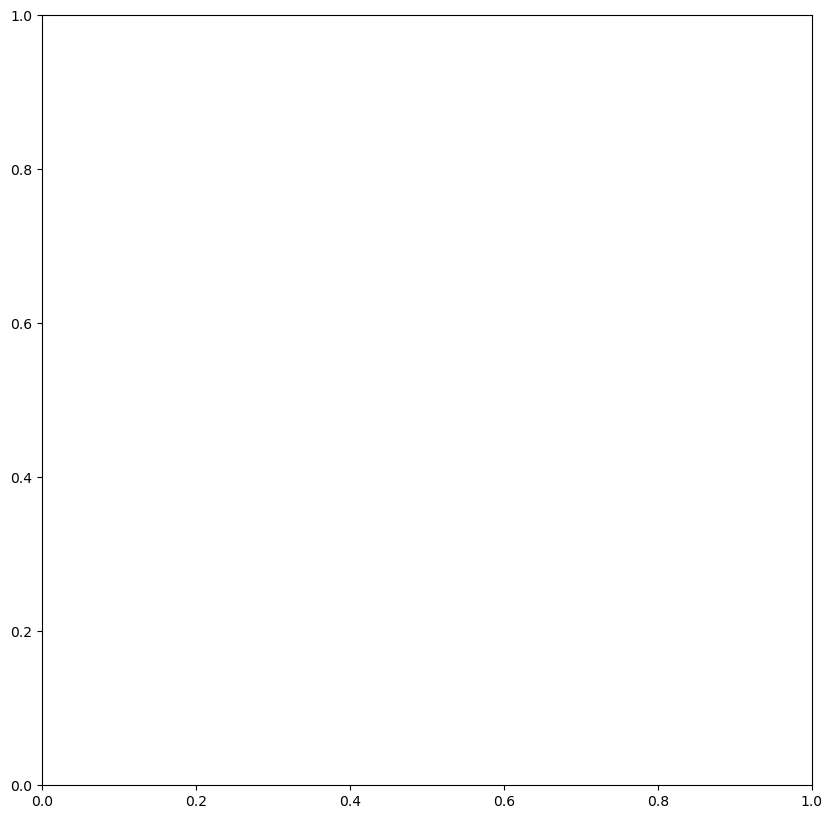

In [128]:
geo_data=geo_data.dropna()
crime_counts = data['AREA NAME'].value_counts().reset_index()
crime_counts.columns = ['AREA NAME', 'Crime Count']
merged_data = geo_data.merge(crime_counts, left_on='STATION', right_on='AREA NAME', how='right')

fig, ax = plt.subplots(figsize=(10, 10))
merged_data.plot(column='Crime Count', ax=ax, legend=True,cmap='Reds',
                legend_kwds={'label': "Crime Count by District", 'orientation': "horizontal"})
ax.set_title("Crime Count Distribution by Reporting District", fontsize=15)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Show the plot
plt.show()



In [ ]:
"""# Step 1: Inspect the unique values in join columns
print("Unique AREA NAMEs in data:", data['AREA NAME'].nunique())
print("Unique STATIONs in geo_data:", geo_data['STATION'].nunique())

print("\nSample AREA NAMEs:", data['AREA NAME'].unique()[:5])
print("Sample STATIONs:", geo_data['STATION'].unique()[:5])

# Step 2: Drop duplicates in join columns (to prevent bloat)
data_clean = data.drop_duplicates(subset='AREA NAME')
geo_clean = geo_data.drop_duplicates(subset='STATION')

# Step 3: Select only needed columns from geo_data (reduce memory usage)
geo_subset = geo_clean[['STATION', 'geometry']]  # Add other columns if needed

# Step 4: Test with inner join (no memory explosion)
test_merge = data_clean.merge(geo_subset, left_on='AREA NAME', right_on='STATION', how='inner')
print("Inner join result shape:", test_merge.shape)
"""



'# Step 1: Inspect the unique values in join columns\nprint("Unique AREA NAMEs in data:", data[\'AREA NAME\'].nunique())\nprint("Unique STATIONs in geo_data:", geo_data[\'STATION\'].nunique())\n\nprint("\nSample AREA NAMEs:", data[\'AREA NAME\'].unique()[:5])\nprint("Sample STATIONs:", geo_data[\'STATION\'].unique()[:5])\n\n# Step 2: Drop duplicates in join columns (to prevent bloat)\ndata_clean = data.drop_duplicates(subset=\'AREA NAME\')\ngeo_clean = geo_data.drop_duplicates(subset=\'STATION\')\n\n# Step 3: Select only needed columns from geo_data (reduce memory usage)\ngeo_subset = geo_clean[[\'STATION\', \'geometry\']]  # Add other columns if needed\n\n# Step 4: Test with inner join (no memory explosion)\ntest_merge = data_clean.merge(geo_subset, left_on=\'AREA NAME\', right_on=\'STATION\', how=\'inner\')\nprint("Inner join result shape:", test_merge.shape)\n'

In [ ]:
"""# Step 5: If inner join looks okay, perform full left join on original data
merged_data = data.merge(geo_subset, left_on='AREA NAME', right_on='STATION', how='left')

# Step 6: Check result
print("Final merged data shape:", merged_data.shape)
merged_data.head()"""

'# Step 5: If inner join looks okay, perform full left join on original data\nmerged_data = data.merge(geo_subset, left_on=\'AREA NAME\', right_on=\'STATION\', how=\'left\')\n\n# Step 6: Check result\nprint("Final merged data shape:", merged_data.shape)\nmerged_data.head()'

In [ ]:

"""poverty_df = pd.read_csv("poverty_data.csv")
census_gdf = gpd.read_file("2020_Census_Tracts.shp")
poverty_df['Census Tract 2020'] = poverty_df['Census Tract 2020'].astype(str)
census_gdf['CT20'] = census_gdf['CT20'].astype(str)
census_poverty = census_gdf.merge(poverty_df, left_on='CT20', right_on='Census Tract 2020', how='left')
census_poverty = census_poverty.to_crs(epsg=3857)
choropleth_vars = {
    "Poverty Rate": "Poverty Rate (%)",
    "Median Household Income": "Median Income ($)",
    "Percentage of Less Than High School Graduate": "Less Than HS Edu (%)",
    "Percentage of Household Without Internet Access": "No Internet Access (%)",
    "Percentage of Hispanic": "Hispanic (%)"
}
n_cols = 2
n_rows = (len(choropleth_vars) + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 6))

axes = axes.flatten()  # flatten in case of single row

for i, (col, title) in enumerate(choropleth_vars.items()):
    census_poverty.plot(
        column=col,
        ax=axes[i],
        cmap='OrRd',
        edgecolor='black',
        linewidth=0.2,
        legend=True,
        legend_kwds={'label': title}
    )
    axes[i].set_title(title, fontsize=14)
    axes[i].axis('off')

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()"""


'poverty_df = pd.read_csv("poverty_data.csv")\ncensus_gdf = gpd.read_file("2020_Census_Tracts.shp")\npoverty_df[\'Census Tract 2020\'] = poverty_df[\'Census Tract 2020\'].astype(str)\ncensus_gdf[\'CT20\'] = census_gdf[\'CT20\'].astype(str)\ncensus_poverty = census_gdf.merge(poverty_df, left_on=\'CT20\', right_on=\'Census Tract 2020\', how=\'left\')\ncensus_poverty = census_poverty.to_crs(epsg=3857)\nchoropleth_vars = {\n    "Poverty Rate": "Poverty Rate (%)",\n    "Median Household Income": "Median Income ($)",\n    "Percentage of Less Than High School Graduate": "Less Than HS Edu (%)",\n    "Percentage of Household Without Internet Access": "No Internet Access (%)",\n    "Percentage of Hispanic": "Hispanic (%)"\n}\nn_cols = 2\nn_rows = (len(choropleth_vars) + 1) // n_cols\nfig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 6))\n\naxes = axes.flatten()  # flatten in case of single row\n\nfor i, (col, title) in enumerate(choropleth_vars.items()):\n    census_poverty.plot(\n 

In [ ]:
"""from folium.plugins import HeatMap
import folium

# --- Create base map ---
m = folium.Map(location=[34.05, -118.25], zoom_start=10)

# --- Add poverty choropleth ---
folium.Choropleth(
    geo_data=census_poverty,
    data=census_poverty,
    columns=["CT20", "Poverty Rate"],
    key_on="feature.properties.CT20",
    fill_color='YlOrRd',
    fill_opacity=0.6,
    line_opacity=0.3,
    legend_name='Poverty Rate (%)'
).add_to(m)

# --- Add crime heatmap (LAT/LON must be in EPSG:4326) ---
from shapely.geometry import Point

# Recreate geometry in lat/lon if needed
crime_heat = merged_data.copy()
crime_heat = crime_heat[(crime_heat["LAT"].notna()) & (crime_heat["LON"].notna())]
heat_data = crime_heat[['LAT', 'LON']].values.tolist()

HeatMap(heat_data, radius=10, blur=7, name="Crime Hotspots").add_to(m)

# --- Add layer control ---
folium.LayerControl().add_to(m)

# --- Save map ---
m.save("poverty_vs_crime_hotspots.html")
print("✅ Saved interactive map with poverty + crime hotspots.")"""


'from folium.plugins import HeatMap\nimport folium\n\n# --- Create base map ---\nm = folium.Map(location=[34.05, -118.25], zoom_start=10)\n\n# --- Add poverty choropleth ---\nfolium.Choropleth(\n    geo_data=census_poverty,\n    data=census_poverty,\n    columns=["CT20", "Poverty Rate"],\n    key_on="feature.properties.CT20",\n    fill_color=\'YlOrRd\',\n    fill_opacity=0.6,\n    line_opacity=0.3,\n    legend_name=\'Poverty Rate (%)\'\n).add_to(m)\n\n# --- Add crime heatmap (LAT/LON must be in EPSG:4326) ---\nfrom shapely.geometry import Point\n\n# Recreate geometry in lat/lon if needed\ncrime_heat = merged_data.copy()\ncrime_heat = crime_heat[(crime_heat["LAT"].notna()) & (crime_heat["LON"].notna())]\nheat_data = crime_heat[[\'LAT\', \'LON\']].values.tolist()\n\nHeatMap(heat_data, radius=10, blur=7, name="Crime Hotspots").add_to(m)\n\n# --- Add layer control ---\nfolium.LayerControl().add_to(m)\n\n# --- Save map ---\nm.save("poverty_vs_crime_hotspots.html")\nprint("✅ Saved interactiv

In [ ]:
"""#from shapely.geometry import Point
#poverty_df = pd.read_csv("poverty_data.csv")
census_gdf = gpd.read_file("2020_Census_Tracts.shp")

# Merge poverty into census tracts
poverty_df['Census Tract 2020'] = poverty_df['Census Tract 2020'].astype(str)
census_gdf['CT20'] = census_gdf['CT20'].astype(str)
census_poverty = census_gdf.merge(poverty_df, left_on='CT20', right_on='Census Tract 2020', how='left')

# Set CRS for plotting
census_poverty = census_poverty.to_crs(epsg=3857)
crime_df_clean = merged_data[(merged_data['LAT'].notna()) & (merged_data['LON'].notna())]
crime_gdf = gpd.GeoDataFrame(
    crime_df_clean,
    geometry=[Point(xy) for xy in zip(crime_df_clean['LON'], crime_df_clean['LAT'])],
    crs='EPSG:4326'
).to_crs(epsg=3857)

# Extract X and Y for KDE
x = crime_gdf.geometry.x
y = crime_gdf.geometry.y

fig, ax = plt.subplots(figsize=(14, 12))

# Plot poverty rate choropleth
census_poverty.plot(
    column='Poverty Rate',
    cmap='OrRd',
    edgecolor='gray',
    linewidth=0.2,
    legend=True,
    legend_kwds={'label': "Poverty Rate (%)"},
    ax=ax
)

# KDE overlay using seaborn
sns.kdeplot(
    x=x,
    y=y,
    ax=ax,
    cmap="Blues",
    fill=True,
    alpha=0.4,        # transparency to let base layer show through
    bw_adjust=0.5,    # bandwidth tweak for detail
    thresh=0.05       # only show meaningful density
)

ax.set_title("Crime Density Overlayed on Poverty Rate", fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.show()"""


'#from shapely.geometry import Point\n#poverty_df = pd.read_csv("poverty_data.csv")\ncensus_gdf = gpd.read_file("2020_Census_Tracts.shp")\n\n# Merge poverty into census tracts\npoverty_df[\'Census Tract 2020\'] = poverty_df[\'Census Tract 2020\'].astype(str)\ncensus_gdf[\'CT20\'] = census_gdf[\'CT20\'].astype(str)\ncensus_poverty = census_gdf.merge(poverty_df, left_on=\'CT20\', right_on=\'Census Tract 2020\', how=\'left\')\n\n# Set CRS for plotting\ncensus_poverty = census_poverty.to_crs(epsg=3857)\ncrime_df_clean = merged_data[(merged_data[\'LAT\'].notna()) & (merged_data[\'LON\'].notna())]\ncrime_gdf = gpd.GeoDataFrame(\n    crime_df_clean,\n    geometry=[Point(xy) for xy in zip(crime_df_clean[\'LON\'], crime_df_clean[\'LAT\'])],\n    crs=\'EPSG:4326\'\n).to_crs(epsg=3857)\n\n# Extract X and Y for KDE\nx = crime_gdf.geometry.x\ny = crime_gdf.geometry.y\n\nfig, ax = plt.subplots(figsize=(14, 12))\n\n# Plot poverty rate choropleth\ncensus_poverty.plot(\n    column=\'Poverty Rate\',\n  

In [ ]:
""""merged_data_with_poverty = pd.merge(data, poverty_df, on='common_column', how='left')
merged_data_with_poverty_and_districts = pd.merge(merged_data_with_poverty, geo_data, left_on='AREA NAME', right_on='STATION', how='left')
print(merged_data_with_poverty_and_districts.head())"""


'"merged_data_with_poverty = pd.merge(data, poverty_df, on=\'common_column\', how=\'left\')\nmerged_data_with_poverty_and_districts = pd.merge(merged_data_with_poverty, geo_data, left_on=\'AREA NAME\', right_on=\'STATION\', how=\'left\')\nprint(merged_data_with_poverty_and_districts.head())'

In [ ]:
"""print(joined['Crime Category'].unique())
print(joined[['Poverty Rate', 'CrimeCount']].dtypes)
print(joined[['Poverty Rate', 'CrimeCount']].isnull().sum())"""


"print(joined['Crime Category'].unique())\nprint(joined[['Poverty Rate', 'CrimeCount']].dtypes)\nprint(joined[['Poverty Rate', 'CrimeCount']].isnull().sum())"

In [ ]:
"""# Step 1: Keep only valid rows
plot_data = joined[['Poverty Rate', 'CrimeCount', 'Crime Category']].dropna()


plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_data, x='Poverty Rate', y='CrimeCount', hue='Crime Category')
plt.title("Crime Count vs Poverty Rate by Crime Type")
plt.xlabel("Poverty Rate (%)")
plt.ylabel("Crime Count")
plt.tight_layout()
plt.show()"""


'# Step 1: Keep only valid rows\nplot_data = joined[[\'Poverty Rate\', \'CrimeCount\', \'Crime Category\']].dropna()\n\n\nplt.figure(figsize=(10, 6))\nsns.scatterplot(data=plot_data, x=\'Poverty Rate\', y=\'CrimeCount\', hue=\'Crime Category\')\nplt.title("Crime Count vs Poverty Rate by Crime Type")\nplt.xlabel("Poverty Rate (%)")\nplt.ylabel("Crime Count")\nplt.tight_layout()\nplt.show()'

In [ ]:
"""joined=joined.dropna()
## 📊 3. BOXPLOT: Crime Levels in High vs Low Poverty
joined['poverty_bin'] = pd.qcut(joined['Poverty Rate'], q=2, labels=['Low Poverty', 'High Poverty'])
plt.figure(figsize=(8, 5))
sns.boxplot(data=joined, x='poverty_bin', y='CrimeCount')
plt.title("Crime Count by Poverty Level")
plt.ylabel("Crime Count")
plt.xlabel("Poverty Level")
plt.savefig("crime_by_poverty_boxplot.png")
plt.show()"""

'joined=joined.dropna()\n## 📊 3. BOXPLOT: Crime Levels in High vs Low Poverty\njoined[\'poverty_bin\'] = pd.qcut(joined[\'Poverty Rate\'], q=2, labels=[\'Low Poverty\', \'High Poverty\'])\nplt.figure(figsize=(8, 5))\nsns.boxplot(data=joined, x=\'poverty_bin\', y=\'CrimeCount\')\nplt.title("Crime Count by Poverty Level")\nplt.ylabel("Crime Count")\nplt.xlabel("Poverty Level")\nplt.savefig("crime_by_poverty_boxplot.png")\nplt.show()'

In [ ]:
"""used_areas = set()
used_categories = set()
final_rows = pd.DataFrame(columns=crime_category_counts.columns)

for i in range(len(crime_category_counts)):
    row = crime_category_counts.loc[i]
    area = row['AREA NAME']
    category = row['Crime Category']

    if category not in used_categories and area not in used_areas:
        # Add row to final_rows using .at[]
        next_index = len(final_rows)
        final_rows.at[next_index, 'AREA NAME'] = area
        final_rows.at[next_index, 'Crime Category'] = category
        final_rows.at[next_index, 'CrimeCount'] = row['CrimeCount']

        # Mark them as used
        used_categories.add(category)
        used_areas.add(area)

    if len(used_categories) == crime_category_counts['Crime Category'].nunique():
        break

final_rows = final_rows.reset_index(drop=True)

merged_data = geo_data.merge(final_rows, left_on='STATION', right_on='AREA NAME', how='right')
fig, ax = plt.subplots(figsize=(20, 20))
merged_data.plot(column='Crime Category',ax=ax,legend=True)
ax.set_title("Top District per Crime Category", fontsize=15)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()"""

'used_areas = set()\nused_categories = set()\nfinal_rows = pd.DataFrame(columns=crime_category_counts.columns)\n\nfor i in range(len(crime_category_counts)):\n    row = crime_category_counts.loc[i]\n    area = row[\'AREA NAME\']\n    category = row[\'Crime Category\']\n\n    if category not in used_categories and area not in used_areas:\n        # Add row to final_rows using .at[]\n        next_index = len(final_rows)\n        final_rows.at[next_index, \'AREA NAME\'] = area\n        final_rows.at[next_index, \'Crime Category\'] = category\n        final_rows.at[next_index, \'CrimeCount\'] = row[\'CrimeCount\']\n\n        # Mark them as used\n        used_categories.add(category)\n        used_areas.add(area)\n\n    if len(used_categories) == crime_category_counts[\'Crime Category\'].nunique():\n        break\n\nfinal_rows = final_rows.reset_index(drop=True)\n\nmerged_data = geo_data.merge(final_rows, left_on=\'STATION\', right_on=\'AREA NAME\', how=\'right\')\nfig, ax = plt.subplots(fi

In [ ]:
"""merged_data.to_csv('merged_data.csv', encoding = 'utf-8-sig')
from google.colab import files
files.download('merged_data.csv')"""


"merged_data.to_csv('merged_data.csv', encoding = 'utf-8-sig')\nfrom google.colab import files\nfiles.download('merged_data.csv')"

In [ ]:
crime_df = data.copy()
crime_df.duplicated()
# Parse and extract time features
crime_df['Date'] = pd.to_datetime(crime_df['DATE OCC'], errors='coerce')
crime_df['Year'] = crime_df['Date'].dt.year
crime_df['Month'] = crime_df['Date'].dt.month
crime_df['Hour'] = pd.to_numeric(crime_df['Hour'], errors='coerce')

# Population dictionary
district_population_data = {
    'WILSHIRE': 145320, 'CENTRAL': 182765, 'SOUTHWEST': 118940, 'VAN NUYS': 165732,
    'HOLLENBECK': 138210, 'RAMPART': 140875, 'NEWTON': 109432, 'NORTHEAST': 95678,
    '77TH STREET': 107215, 'HOLLYWOOD': 132540, 'HARBOR': 136890, 'WEST VALLEY': 162305,
    'WEST LA': 132450, 'N HOLLYWOOD': 156780, 'PACIFIC': 69540, 'DEVONSHIRE': 125890,
    'MISSION': 160432, 'SOUTHEAST': 124765, 'OLYMPIC': 83210, 'FOOTHILL': 89765, 'TOPANGA': 128540
}
pop_df = pd.DataFrame(list(district_population_data.items()), columns=["AREA NAME", "Population"])

# Monthly crime rate
monthly = crime_df.groupby(['AREA NAME', 'Year', 'Month']).size().reset_index(name='Monthly_Crime_Count')
monthly = monthly.merge(pop_df, on='AREA NAME', how='left')
monthly['Monthly_Crime_Rate_per_1000'] = (monthly['Monthly_Crime_Count'] / monthly['Population']) * 1000
crime_df = crime_df.merge(monthly[['AREA NAME', 'Year', 'Month', 'Monthly_Crime_Rate_per_1000']],
                          on=['AREA NAME', 'Year', 'Month'], how='left')
crime_df.drop_duplicates(inplace=True)

# Yearly crime rate
yearly = crime_df.groupby(['AREA NAME', 'Year']).size().reset_index(name='Yearly_Crime_Count')
yearly = yearly.merge(pop_df, on='AREA NAME', how='left')
yearly['Yearly_Crime_Rate_per_1000'] = (yearly['Yearly_Crime_Count'] / yearly['Population']) * 1000
crime_df = crime_df.merge(yearly[['AREA NAME', 'Year', 'Yearly_Crime_Rate_per_1000']],
                          on=['AREA NAME', 'Year'], how='left')
crime_df.drop_duplicates(inplace=True)


# Hourly crime rate
hourly = crime_df.groupby(['AREA NAME', 'Date', 'Hour']).size().reset_index(name='Hourly_Crime_Count')
hourly = hourly.merge(pop_df, on='AREA NAME', how='left')
hourly['Hourly_Crime_Rate_per_1000'] = (hourly['Hourly_Crime_Count'] / hourly['Population']) * 1000
crime_df = crime_df.merge(hourly[['AREA NAME', 'Date', 'Hour', 'Hourly_Crime_Rate_per_1000']],
                          on=['AREA NAME', 'Date', 'Hour'], how='left')
crime_df.drop_duplicates(inplace=True)



In [ ]:
#Daily crime rate per district
daily = crime_df.groupby(['AREA NAME', 'Date']).size().reset_index(name='Daily_Crime_Count')
daily = daily.merge(pop_df, on='AREA NAME', how='left')
daily['Daily_Crime_Rate_per_1000'] = (daily['Daily_Crime_Count'] / daily['Population']) * 1000

# Merge it into main DataFrame
crime_df = crime_df.merge(daily[['AREA NAME', 'Date', 'Daily_Crime_Rate_per_1000']],
                          on=['AREA NAME', 'Date'], how='left')
crime_df.drop_duplicates(inplace=True)


In [ ]:
crime_df.shape

(819015, 49)

In [ ]:
"""district_population_data = {
     'WILSHIRE': 145320,
    'CENTRAL': 182765,
    'SOUTHWEST': 118940,
    'VAN NUYS': 165732,
    'HOLLENBECK': 138210,
    'RAMPART': 140875,
    'NEWTON': 109432,
    'NORTHEAST': 95678,
    '77TH STREET': 107215,
    'HOLLYWOOD': 132540,
    'HARBOR': 136890,
    'WEST VALLEY': 162305,
    'WEST LA': 132450,
    'N HOLLYWOOD': 156780,
    'PACIFIC': 69540,
    'DEVONSHIRE': 125890,
    'MISSION': 160432,
    'SOUTHEAST': 124765,
    'OLYMPIC': 83210,
    'FOOTHILL': 89765,
    'TOPANGA': 128540
}

# Convert to DataFrame
pop_df = pd.DataFrame(list(district_population_data.items()), columns=["AREA NAME", "Population"])
crime_df=data.copy()
# Ensure Month and Year columns are present
crime_df['Date'] = pd.to_datetime(crime_df['DATE OCC'], errors='coerce')
crime_df['Year'] = crime_df['Date'].dt.year
crime_df['Month'] = crime_df['Date'].dt.month
crime_df['Hour'] = pd.to_numeric(crime_df['Hour'], errors='coerce')

# --- 1. Month-on-Month Normalized Crime Rate (aggregated across all years)
monthly_counts = crime_df.groupby(['AREA NAME','Year', 'Month']).size().reset_index(name='Crime Count')
monthly_df = pd.merge(monthly_counts, pop_df, on='AREA NAME', how='left')
monthly_df['Crime Rate per 1000'] = (monthly_df['Crime Count'] / monthly_df['Population']) * 1000

# --- 2. Year-on-Year  Comparison
yoy_counts = crime_df.groupby(['AREA NAME', 'Year']).size().reset_index(name='Crime Count')
yoy_df = pd.merge(yoy_counts, pop_df, on='AREA NAME', how='left')
yoy_df['Crime Rate per 1000'] = (yoy_df['Crime Count'] / yoy_df['Population']) * 1000

# --- 3. Hour-on-Hour Crime Rate (aggregated)
hourly_counts = crime_df.groupby(['AREA NAME','Date', 'Hour']).size().reset_index(name='Crime Count')
hourly_df = pd.merge(hourly_counts, pop_df, on='AREA NAME', how='left')
hourly_df['Crime Rate per 1000'] = (hourly_df['Crime Count'] / hourly_df['Population']) * 1000

# OPTIONAL: Save to CSV or plot
# monthly_df.to_csv("monthly_crime_rate.csv", index=False)
# yoy_df.to_csv("year_on_year_monthly_crime_rate.csv", index=False)
# hourly_df.to_csv("hourly_crime_rate.csv", index=False)

# Example output
print(monthly_df.head())"""


'district_population_data = {\n     \'WILSHIRE\': 145320,\n    \'CENTRAL\': 182765,\n    \'SOUTHWEST\': 118940,\n    \'VAN NUYS\': 165732,\n    \'HOLLENBECK\': 138210,\n    \'RAMPART\': 140875,\n    \'NEWTON\': 109432,\n    \'NORTHEAST\': 95678,\n    \'77TH STREET\': 107215,\n    \'HOLLYWOOD\': 132540,\n    \'HARBOR\': 136890,\n    \'WEST VALLEY\': 162305,\n    \'WEST LA\': 132450,\n    \'N HOLLYWOOD\': 156780,\n    \'PACIFIC\': 69540,\n    \'DEVONSHIRE\': 125890,\n    \'MISSION\': 160432,\n    \'SOUTHEAST\': 124765,\n    \'OLYMPIC\': 83210,\n    \'FOOTHILL\': 89765,\n    \'TOPANGA\': 128540\n}\n\n# Convert to DataFrame\npop_df = pd.DataFrame(list(district_population_data.items()), columns=["AREA NAME", "Population"])\ncrime_df=data.copy()\n# Ensure Month and Year columns are present\ncrime_df[\'Date\'] = pd.to_datetime(crime_df[\'DATE OCC\'], errors=\'coerce\')\ncrime_df[\'Year\'] = crime_df[\'Date\'].dt.year\ncrime_df[\'Month\'] = crime_df[\'Date\'].dt.month\ncrime_df[\'Hour\'] = pd.

In [ ]:
crime_df["DATE OCC"] = pd.to_datetime(crime_df["DATE OCC"], errors='coerce')
crime_df["Hour"] = pd.to_numeric(crime_df["Hour"], errors='coerce')
crime_df["Datetime_Key"] = crime_df["DATE OCC"].dt.floor("d") + pd.to_timedelta(crime_df["Hour"], unit="h")
crime_df["Date"] = pd.to_datetime(crime_df["DATE OCC"], errors="coerce").dt.date
crime_df["Hour"] = pd.to_numeric(crime_df["Hour"], errors="coerce")
crime_df["is_daily_hotspot"] = crime_df.groupby("Date")["Daily_Crime_Rate_per_1000"].transform(
    lambda x: (x > x.quantile(0.75)).astype(int)
)
crime_df = crime_df.sort_values(["AREA NAME", "Datetime_Key"])
crime_df.drop_duplicates(inplace=True)

# Rolling mean & std over past 24 hours (per district)
crime_df["rolling_mean"] = (
    crime_df.groupby("AREA NAME")["Hourly_Crime_Rate_per_1000"]
    .transform(lambda x: x.rolling(window=24, min_periods=12).mean())
)
crime_df.drop_duplicates(inplace=True)

crime_df["rolling_std"] = (
    crime_df.groupby("AREA NAME")["Hourly_Crime_Rate_per_1000"]
    .transform(lambda x: x.rolling(window=24, min_periods=12).std())
)
crime_df.drop_duplicates(inplace=True)

# Z-score computation
crime_df["z_score"] = (
    (crime_df["Hourly_Crime_Rate_per_1000"] - crime_df["rolling_mean"]) / crime_df["rolling_std"]
)

# Define as hotspot if z-score exceeds threshold
z_threshold = 1.5
crime_df["is_hourly_hotspot"] = (crime_df["z_score"] > z_threshold).astype(int)

# Optional: Keep Datetime_Hour_Key if needed for grouping later
crime_df["Datetime_Hour_Key"] = crime_df["Date"].astype(str) + "_" + crime_df["Hour"].astype(str)

# --- 3. Monthly Hotspot: top 25%-ile of districts in each month ---
crime_df["YearMonth_Key"] = crime_df["Year"].astype(str) + "_" + crime_df["Month"].astype(str)
crime_df["is_monthly_hotspot"] = crime_df.groupby("YearMonth_Key")["Monthly_Crime_Rate_per_1000"].transform(
    lambda x: (x > x.quantile(0.75)).astype(int)
)
crime_df.drop_duplicates(inplace=True)

# --- 4. Yearly Hotspot: top 25%-ile of districts per year ---
crime_df["is_yearly_hotspot"] = crime_df.groupby("Year")["Yearly_Crime_Rate_per_1000"].transform(
    lambda x: (x > x.quantile(0.75)).astype(int)
)
crime_df.drop_duplicates(inplace=True)



In [ ]:
crime_df.shape

(819015, 59)

In [ ]:
# --- Lag Features ---
# 1. Last 1 hour
crime_df["crime_rate_last_1h"] = crime_df.groupby("AREA NAME")["Hourly_Crime_Rate_per_1000"].shift(1)

# 2. Last 3 hour rolling average
crime_df["crime_rate_last_3h_avg"] = (
    crime_df.groupby("AREA NAME")["Hourly_Crime_Rate_per_1000"]
    .rolling(3, min_periods=1).mean().shift(1).reset_index(level=0, drop=True)
)

# 3. Last 6 hour rolling sum
crime_df["crime_rate_last_6h_sum"] = (
    crime_df.groupby("AREA NAME")["Hourly_Crime_Rate_per_1000"]
    .rolling(6, min_periods=1).sum().shift(1).reset_index(level=0, drop=True)
)

# 4. Yesterday same hour
crime_df["Datetime_Prev_Day"] = crime_df["Datetime_Key"] - pd.Timedelta(days=1)
crime_df["Prev_Day_Key"] = crime_df["AREA NAME"] + "_" + crime_df["Datetime_Prev_Day"].dt.strftime("%Y-%m-%d_%H")

lookup_df = crime_df[["AREA NAME", "Datetime_Key", "Hourly_Crime_Rate_per_1000"]].copy()
lookup_df["Lookup_Key"] = lookup_df["AREA NAME"] + "_" + lookup_df["Datetime_Key"].dt.strftime("%Y-%m-%d_%H")
lookup_dict = lookup_df.set_index("Lookup_Key")["Hourly_Crime_Rate_per_1000"].to_dict()

crime_df["crime_rate_yesterday_same_hour"] = crime_df["Prev_Day_Key"].map(lookup_dict)
crime_df.drop_duplicates(inplace=True)

# 5. Hotspot last hour
crime_df["was_hourly_hotspot_last_hour"] = crime_df.groupby("AREA NAME")["is_hourly_hotspot"].shift(1)

# 6. Daily hotspot yesterday
crime_df["Date_Yesterday"] = crime_df["Date"] - pd.Timedelta(days=1)
daily_hotspot_map = crime_df.drop_duplicates(["AREA NAME", "Date"])[["AREA NAME", "Date", "is_daily_hotspot"]]
daily_hotspot_map = daily_hotspot_map.rename(columns={"Date": "Date_Yesterday", "is_daily_hotspot": "was_daily_hotspot_yesterday"})
crime_df = crime_df.merge(daily_hotspot_map, on=["AREA NAME", "Date_Yesterday"], how="left")
crime_df.drop_duplicates(inplace=True)


# 7. Hotspot same day last year
crime_df["Date_Last_Year"] = crime_df["Datetime_Key"] - pd.DateOffset(years=1)
crime_df["Last_Year_Key"] = crime_df["AREA NAME"] + "_" + crime_df["Date_Last_Year"].dt.strftime("%Y-%m-%d")
# 8. Daily hotspot 
year_lookup_df = crime_df.drop_duplicates(["AREA NAME", "Date"])[["AREA NAME", "Date", "is_daily_hotspot"]].copy()
year_lookup_df["Year_Key"] = year_lookup_df["AREA NAME"] + "_" + pd.to_datetime(year_lookup_df["Date"]).dt.strftime("%Y-%m-%d")
year_lookup_dict = year_lookup_df.set_index("Year_Key")["is_daily_hotspot"].to_dict()
crime_df["was_hotspot_last_year_same_day"] = crime_df["Last_Year_Key"].map(year_lookup_dict)


In [ ]:
"""from datetime import datetime
from meteostat import Point, Hourly
import boto3
from io import StringIO
import warnings
import time

warnings.simplefilter(action='ignore', category=FutureWarning)

# Clean and prepare crime_df
crime_df = crime_df.dropna(subset=["LAT", "LON", "AREA NAME"])
crime_df["Date"] = pd.to_datetime(crime_df["DATE OCC"], errors="coerce")
crime_df["Hour"] = pd.to_numeric(crime_df["Hour"], errors="coerce")
crime_df = crime_df.dropna(subset=["AREA NAME", "Date", "Hour"])

# Round datetime to nearest hour
crime_df["Datetime_Key"] = crime_df["Date"].dt.floor('h')

# Calculate centroids and merge directly
centroids = crime_df.groupby("AREA NAME")[["LAT", "LON"]].mean().rename(columns={"LAT": "Center_LAT", "LON": "Center_LON"})
crime_df = crime_df.merge(centroids, on="AREA NAME", how="left")

# Create unique (district + time) key
crime_df["Coord_Time_Key"] = crime_df["AREA NAME"].astype(str) + "_" + crime_df["Datetime_Key"].astype(str)

# Unique fetch set
fetch_df = crime_df[["Coord_Time_Key", "Center_LAT", "Center_LON", "Datetime_Key"]].drop_duplicates()

# Fetch weather batch
def fetch_weather_batch(df):
    weather_data = {}
    for idx, row in df.iterrows():
        key = row["Coord_Time_Key"]
        try:
            loc = Point(row["Center_LAT"], row["Center_LON"])
            data = Hourly(loc, row["Datetime_Key"], row["Datetime_Key"]).fetch()
            if not data.empty:
                weather_data[key] = {
                    "Temp": data.iloc[0]["temp"],
                    "Wspeed": data.iloc[0]["wspd"]
                }
            else:
                weather_data[key] = {"Temp": None, "Wspeed": None}
        except Exception as e:
            print(f"Error fetching {key}: {e}")
            weather_data[key] = {"Temp": None, "Wspeed": None}
        
        # Tiny sleep to avoid too many rapid requests
        time.sleep(0.1)
        
    return weather_data

weather_lookup = fetch_weather_batch(fetch_df)

# Map weather back to crime_df
weather_df = crime_df["Coord_Time_Key"].map(weather_lookup)
weather_df = pd.json_normalize(weather_df)

# Merge
crime_df = pd.concat([crime_df.reset_index(drop=True), weather_df], axis=1)

# Step 7: Keep only necessary columns
final_crime_df = crime_df[["DR_NO", "Temp", "Wspeed"]].drop_duplicates()

# Save to S3
def save_to_s3(df, bucket_name, file_name):
    csv_buffer = StringIO()
    df.to_csv(csv_buffer, index=False)
    s3_client = boto3.client('s3')
    s3_client.put_object(Bucket=bucket_name, Key=file_name, Body=csv_buffer.getvalue())
    print(f"File uploaded to s3://{bucket_name}/{file_name}")

# Auto-timestamp the filename
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
file_name = f"crime_with_temp_wspeed_only_{timestamp}.csv"

# Upload
save_to_s3(final_crime_df, bucket_name="mlc-final", file_name=file_name)
"""



'from datetime import datetime\nfrom meteostat import Point, Hourly\nimport boto3\nfrom io import StringIO\nimport warnings\nimport time\n\nwarnings.simplefilter(action=\'ignore\', category=FutureWarning)\n\n# Clean and prepare crime_df\ncrime_df = crime_df.dropna(subset=["LAT", "LON", "AREA NAME"])\ncrime_df["Date"] = pd.to_datetime(crime_df["DATE OCC"], errors="coerce")\ncrime_df["Hour"] = pd.to_numeric(crime_df["Hour"], errors="coerce")\ncrime_df = crime_df.dropna(subset=["AREA NAME", "Date", "Hour"])\n\n# Round datetime to nearest hour\ncrime_df["Datetime_Key"] = crime_df["Date"].dt.floor(\'h\')\n\n# Calculate centroids and merge directly\ncentroids = crime_df.groupby("AREA NAME")[["LAT", "LON"]].mean().rename(columns={"LAT": "Center_LAT", "LON": "Center_LON"})\ncrime_df = crime_df.merge(centroids, on="AREA NAME", how="left")\n\n# Create unique (district + time) key\ncrime_df["Coord_Time_Key"] = crime_df["AREA NAME"].astype(str) + "_" + crime_df["Datetime_Key"].astype(str)\n\n# Uni

In [ ]:
new_df = pd.read_csv("weather_data_final.csv")
new_df.head()
new_df.drop_duplicates(inplace=True)

# Convert 'DATE OCC' to datetime in both DataFrames to ensure matching types
new_df['DATE OCC'] = pd.to_datetime(new_df['DATE OCC'])
crime_df['DATE OCC'] = pd.to_datetime(crime_df['DATE OCC'])

# Now perform the merge with matching data types
crime_df = crime_df.merge(
    new_df[['AREA NAME', 'DATE OCC', 'Hour', 'Temp', 'Wspeed']], 
    on=['AREA NAME', 'DATE OCC', 'Hour'], 
    how='left'
)
crime_df.drop_duplicates(inplace=True)


In [121]:
crime_df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Weapon Used Cd,Weapon Desc,Status,Status Desc,LOCATION,LAT,LON,Year,Quarter,Weekend,Date,WeekType,Crime Category,Crime Severity,Simplified Vict Descent,IsHoliday,IsWeekendorHoliday,Crimes_by_Area,Crimes_by_Area_Year,Crimes_by_Area_Year_Month,Crimes_by_Area_Category,Crimes_by_Area_Category_Year,Crimes_by_Area_Category_Year_Month,Crimes_by_Area_Severity,Crimes_by_Area_Severity_Year,Crimes_by_Area_Severity_Year_Month,Monthly_Crime_Rate_per_1000,Yearly_Crime_Rate_per_1000,Hourly_Crime_Rate_per_1000,Daily_Crime_Rate_per_1000,Datetime_Key,is_daily_hotspot,rolling_mean,rolling_std,z_score,is_hourly_hotspot,Datetime_Hour_Key,YearMonth_Key,is_monthly_hotspot,is_yearly_hotspot,crime_rate_last_1h,crime_rate_last_3h_avg,crime_rate_last_6h_sum,Datetime_Prev_Day,Prev_Day_Key,crime_rate_yesterday_same_hour,was_hourly_hotspot_last_hour,Date_Yesterday,was_daily_hotspot_yesterday,Date_Last_Year,Last_Year_Key,was_hotspot_last_year_same_day,Temp,Wspeed,Hour_sin,Hour_cos,DayOfWeek_sin,DayOfWeek_cos,Month_sin,Month_cos
0,201204157,01/02/2020 12:00:00 AM,2020-01-01,0001,12,77TH STREET,1258,2,354,THEFT OF IDENTITY,0100,48.0,F,B,101.0,STREET,Weapon Usage Not Known,Unknown,IC,Invest Cont,7600 S BROADWAY,33.9708,-118.2783,2020,1,Weekday,2020-01-01,Weekday,FRAUD & FINANCIAL CRIMES,Less Serious,Black,True,True,49188,11756,1194,4420,566,93,23486,5613,589,11.136501,109.648836,0.121252,0.72751,2020-01-01,1,NaN,NaN,NaN,0,2020-01-01_0,2020_1,1,1,NaN,NaN,NaN,2019-12-31,77TH STREET_2019-12-31_00,NaN,NaN,2019-12-31,NaN,2019-01-01,77TH STREET_2019-01-01,NaN,20.209677,1.000925,0.0,1.0,0.974928,-0.222521,0.5,0.866025
1,201204157,01/02/2020 12:00:00 AM,2020-01-01,0001,12,77TH STREET,1258,2,354,THEFT OF IDENTITY,0100,48.0,F,B,101.0,STREET,Weapon Usage Not Known,Unknown,IC,Invest Cont,7600 S BROADWAY,33.9708,-118.2783,2020,1,Weekday,2020-01-01,Weekday,FRAUD & FINANCIAL CRIMES,Less Serious,Black,True,True,49188,11756,1194,4420,566,93,23486,5613,589,11.136501,109.648836,0.121252,0.72751,2020-01-01,1,NaN,NaN,NaN,0,2020-01-01_0,2020_1,1,1,NaN,NaN,NaN,2019-12-31,77TH STREET_2019-12-31_00,NaN,NaN,2019-12-31,NaN,2019-01-01,77TH STREET_2019-01-01,NaN,21.101173,1.075896,0.0,1.0,0.974928,-0.222521,0.5,0.866025
2,201204157,01/02/2020 12:00:00 AM,2020-01-01,0001,12,77TH STREET,1258,2,354,THEFT OF IDENTITY,0100,48.0,F,B,101.0,STREET,Weapon Usage Not Known,Unknown,IC,Invest Cont,7600 S BROADWAY,33.9708,-118.2783,2020,1,Weekday,2020-01-01,Weekday,FRAUD & FINANCIAL CRIMES,Less Serious,Black,True,True,49188,11756,1194,4420,566,93,23486,5613,589,11.136501,109.648836,0.121252,0.72751,2020-01-01,1,NaN,NaN,NaN,0,2020-01-01_0,2020_1,1,1,NaN,NaN,NaN,2019-12-31,77TH STREET_2019-12-31_00,NaN,NaN,2019-12-31,NaN,2019-01-01,77TH STREET_2019-01-01,NaN,20.972152,2.103562,0.0,1.0,0.974928,-0.222521,0.5,0.866025
3,201204157,01/02/2020 12:00:00 AM,2020-01-01,0001,12,77TH STREET,1258,2,354,THEFT OF IDENTITY,0100,48.0,F,B,101.0,STREET,Weapon Usage Not Known,Unknown,IC,Invest Cont,7600 S BROADWAY,33.9708,-118.2783,2020,1,Weekday,2020-01-01,Weekday,FRAUD & FINANCIAL CRIMES,Less Serious,Black,True,True,49188,11756,1194,4420,566,93,23486,5613,589,11.136501,109.648836,0.121252,0.72751,2020-01-01,1,NaN,NaN,NaN,0,2020-01-01_0,2020_1,1,1,NaN,NaN,NaN,2019-12-31,77TH STREET_2019-12-31_00,NaN,NaN,2019-12-31,NaN,2019-01-01,77TH STREET_2019-01-01,NaN,20.203675,1.237885,0.0,1.0,0.974928,-0.222521,0.5,0.866025
4,201204157,01/02/2020 12:00:00 AM,2020-01-01,0001,12,77TH STREET,1258,2,354,THEFT OF IDENTITY,0100,48.0,F,B,101.0,STREET,Weapon Usage Not Known,Unknown,IC,Invest Cont,7600 S BROADWAY,33.9708,-118.2783,2020,1,Weekday,2020-01-01,Weekday,FRAUD & FINANCIAL CRIMES,Less Serious,Black,True,True,49188,11756,1194,4420,566,93,23486,5613,589,11.136501,109.648836,0.121252,0.72751,2020-01-01,1,NaN,NaN,NaN,0,2020-01-01_0,2020_1,1,1,NaN,NaN,NaN,2019-12-31,77TH STREET_2019-12-31

In [ ]:
# Fill missing weather data logically
crime_df["Temp"] = crime_df.groupby("AREA NAME")["Temp"].transform(lambda x: x.fillna(x.mean()))
crime_df["Wspeed"] = crime_df.groupby("AREA NAME")["Wspeed"].transform(lambda x: x.fillna(x.mean()))
# No data = no rain assumption
# Drop or convert WeatherCondition
crime_df.drop_duplicates(inplace=True)


In [ ]:
"""def mutate_weather_bidirectional_safe(row):
    if row["is_hourly_hotspot"] == 1:
        # 🔥 Hotspot-friendly mutation
        row["Temp"] += np.random.uniform(1.5, 3.5)
        row["Wspeed"] -= np.random.uniform(1.0, 2.0)
    else:
        # ❄️ Non-hotspot penalty mutation
        row["Temp"] -= np.random.uniform(1.0, 2.0)
        row["Wspeed"] += np.random.uniform(1.0, 2.5)
    
    # 🚫 Clamp values to realistic bounds
    row["Temp"] = max(row["Temp"], 10)
    row["Wspeed"] = max(row["Wspeed"], 0.1)

    return row
"""

In [ ]:
"""crime_df[["Temp","Wspeed"]] = crime_df[["Temp",  "Wspeed"]].astype("float32")
crime_df.fillna(0)
crime_df = crime_df.apply(mutate_weather_bidirectional_safe, axis=1)
print("Mutated safely — no negative or unrealistic values.")
"""

In [ ]:
""""common_cols = crime_df.columns.intersection(new_df.columns)

# Keep only common columns
df_common = crime_df[common_cols]

df_common=df_common.drop('Prec', axis=1, errors='ignore')"""

In [ ]:
"""df_common.head()
df_common.to_csv("weather_data_final.csv", index=False)
"""

In [ ]:
# Convert Hour (0–23) to cyclical
crime_df["Hour_sin"] = np.sin(2 * np.pi * crime_df["Hour"] / 24)
crime_df["Hour_cos"] = np.cos(2 * np.pi * crime_df["Hour"] / 24)

# Convert DayOfWeek (0–6)
crime_df["DayOfWeek_sin"] = np.sin(2 * np.pi * crime_df["DayOfWeek"] / 7)
crime_df["DayOfWeek_cos"] = np.cos(2 * np.pi * crime_df["DayOfWeek"] / 7)

# Convert Month (1–12)
crime_df["Month_sin"] = np.sin(2 * np.pi * crime_df["Month"] / 12)
crime_df["Month_cos"] = np.cos(2 * np.pi * crime_df["Month"] / 12)

In [ ]:
# Now you can select all columns including the weather data
selected_cols = [
    # Time
    "Datetime_Key", "Hour_sin", "DayOfWeek_cos","DayOfWeek_sin", "Month_sin","Month_cos", "Year","Hour_cos",
    "IsHoliday", "IsWeekendorHoliday", "Weekend",

    # Location
    "AREA NAME",

    # Crime rate signals
    "Hourly_Crime_Rate_per_1000", "Daily_Crime_Rate_per_1000",
    "Monthly_Crime_Rate_per_1000", "Yearly_Crime_Rate_per_1000",

    # Lag features
    "crime_rate_last_1h", "crime_rate_last_3h_avg", "crime_rate_last_6h_sum",
    "crime_rate_yesterday_same_hour", "was_hourly_hotspot_last_hour",
    "was_daily_hotspot_yesterday", "was_hotspot_last_year_same_day",

    # Weather
    "Temp", "Wspeed",

    # Target
    "is_hourly_hotspot"
]

model_df = crime_df[selected_cols].fillna(0).drop_duplicates(subset=["Datetime_Key","AREA NAME"])


In [ ]:
"""df = model_df.copy().dropna()
df = df.sort_values("Datetime_Key")

features_to_exclude = [
    "is_hourly_hotspot", "Hourly_Crime_Rate_per_1000",  # Label leakage
    "Datetime_Key",'Prec'
]

split_index = int(len(df) * 0.8)
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

y_train = train_df["is_hourly_hotspot"]
y_test = test_df["is_hourly_hotspot"]

X_train = train_df.drop(columns=features_to_exclude).select_dtypes(include=[np.number])
X_test = test_df.drop(columns=features_to_exclude).select_dtypes(include=[np.number])
"""

'df = model_df.copy().dropna()\ndf = df.sort_values("Datetime_Key")\n\nfeatures_to_exclude = [\n    "is_hourly_hotspot", "Hourly_Crime_Rate_per_1000",  # Label leakage\n    "Datetime_Key",\'Prec\'\n]\n\nsplit_index = int(len(df) * 0.8)\ntrain_df = df.iloc[:split_index]\ntest_df = df.iloc[split_index:]\n\ny_train = train_df["is_hourly_hotspot"]\ny_test = test_df["is_hourly_hotspot"]\n\nX_train = train_df.drop(columns=features_to_exclude).select_dtypes(include=[np.number])\nX_test = test_df.drop(columns=features_to_exclude).select_dtypes(include=[np.number])\n'

In [122]:
crime_df.duplicated().value_counts()

False    2052564
Name: count, dtype: int64

In [ ]:
crime_df.drop(columns=["Hour", "DayOfWeek", "Month"], inplace=True)


In [123]:
crime_df.is_hourly_hotspot.value_counts()

is_hourly_hotspot
0    1606127
1     446437
Name: count, dtype: int64

In [ ]:
model_df.head(100)

,Datetime_Key,Hour_sin,DayOfWeek_cos,DayOfWeek_sin,Month_sin,Month_cos,Year,Hour_cos,IsHoliday,IsWeekendorHoliday,Weekend,AREA NAME,Hourly_Crime_Rate_per_1000,Daily_Crime_Rate_per_1000,Monthly_Crime_Rate_per_1000,Yearly_Crime_Rate_per_1000,crime_rate_last_1h,crime_rate_last_3h_avg,crime_rate_last_6h_sum,crime_rate_yesterday_same_hour,was_hourly_hotspot_last_hour,was_daily_hotspot_yesterday,was_hotspot_last_year_same_day,Temp,Prec,Wspeed,is_hourly_hotspot
0,2020-01-01 00:00:00,0.000000e+00,-0.222521,0.974928,0.5,0.866025,2020,1.000000e+00,True,True,Weekday,77TH STREET,0.121252,0.727510,11.136501,109.648836,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,22.2,0.0,0.0,0
169,2020-01-01 01:00:00,2.588190e-01,-0.222521,0.974928,0.5,0.866025,2020,9.659258e-01,True,True,Weekday,77TH STREET,0.009327,0.727510,11.136501,109.648836,0.121252,0.121252,0.727510,0.000000,0.0,0.0,0.0,22.2,0.0,0.0,0
170,2020-01-01 02:00:00,5.000000e-01,-0.222521,0.974928,0.5,0.866025,2020,8.660254e-01,True,True,Weekday,77TH STREET,0.046635,0.727510,11.136501,109.648836,0.009327,0.083943,0.615586,0.000000,0.0,0.0,0.0,22.2,0.0,0.0,0
195,2020-01-01 03:00:00,7.071068e-01,-0.222521,0.974928,0.5,0.866025,2020,7.071068e-01,True,True,Weekday,77TH STREET,0.018654,0.727510,11.136501,109.648836,0.046635,0.046635,0.242503,0.000000,0.0,0.0,0.0,22.2,0.0,0.0,0
199,2020-01-01 04:00:00,8.660254e-01,-0.222521,0.974928,0.5,0.866025,2020,5.000000e-01,True,True,Weekday,77TH STREET,0.046635,0.727510,11.136501,109.648836,0.018654,0.027981,0.223849,0.000000,0.0,0.0,0.0,22.2,0.0,0.0,0
224,2020-01-01 07:00:00,9.659258e-01,-0.222521,0.974928,0.5,0.866025,2020,-2.588190e-01,True,True,Weekday,77TH STREET,0.009327,0.727510,11.136501,109.648836,0.046635,0.046635,0.251830,0.000000,0.0,0.0,0.0,22.2,0.0,0.0,0
225,2020-01-01 08:00:00,8.660254e-01,-0.222521,0.974928,0.5,0.866025,2020,-5.000000e-01,True,True,Weekday,77TH STREET,0.046635,0.727510,11.136501,109.648836,0.009327,0.034199,0.242503,0.000000,0.0,0.0,0.0,22.2,0.0,0.0,0
250,2020-01-01 09:00:00,7.071068e-01,-0.222521,0.974928,0.5,0.866025,2020,-7.071068e-01,True,True,Weekday,77TH STREET,0.009327,0.727510,11.136501,109.648836,0.046635,0.046635,0.242503,0.000000,0.0,0.0,0.0,22.2,0.0,0.0,0
251,2020-01-01 10:00:00,5.000000e-01,-0.222521,0.974928,0.5,0.866025,2020,-8.660254e-01,True,True,Weekday,77TH STREET,0.046635,0.727510,11.136501,109.648836,0.009327,0.034199,0.242503,0.000000,0.0,0.0,0.0,22.2,0.0,0.0,0
276,2020-01-01 11:00:00,2.588190e-01,-0.222521,0.974928,0.5,0.866025,2020,-9.659258e-01,True,True,Weekday,77TH STREET,0.009327,0.727510,11.136501,109.648836,0.046635,0.046635,0.242503,0.000000,0.0,0.0,0.0,22.2,0.0,0.0,0


In [ ]:
"""df = model_df.copy().dropna()
df = df.sort_values("Datetime_Key")

features_to_exclude = [
    "is_hourly_hotspot", "Hourly_Crime_Rate_per_1000",  
    "Datetime_Key",'Prec'
]

split_index = int(len(df) * 0.8)
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

y_train = train_df["is_hourly_hotspot"]
y_test = test_df["is_hourly_hotspot"]

X_train = train_df.drop(columns=features_to_exclude).select_dtypes(include=[np.number])
X_test = test_df.drop(columns=features_to_exclude).select_dtypes(include=[np.number])"""

In [ ]:
""""rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# ----- Step 5: Predict & Evaluate -----
y_pred_unbalanced = rf_unbalanced.predict(X_test)

print("📊 Classification Report (No SMOTE):")
print(classification_report(y_test, y_pred_unbalanced))

print("\n📉 Confusion Matrix (No SMOTE):")
conf_matrix_unbalanced = confusion_matrix(y_test, y_pred_unbalanced)
sns.heatmap(conf_matrix_unbalanced, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Not Hotspot", "Hotspot"], 
            yticklabels=["Not Hotspot", "Hotspot"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (No SMOTE)")
plt.tight_layout()
plt.show()

# ----- Step 6: Feature Importances -----
importances_unbalanced = pd.Series(rf_unbalanced.feature_importances_, index=X_train.columns).sort_values(ascending=True)
plt.figure(figsize=(10, 12))
importances_unbalanced.plot(kind="barh")
plt.title("Feature Importances (Random Forest No SMOTE)")
plt.tight_layout()
plt.show()"""

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     85688
           1       0.52      0.31      0.39      5369

    accuracy                           0.94     91057
   macro avg       0.74      0.64      0.68     91057
weighted avg       0.93      0.94      0.94     91057


Confusion Matrix:


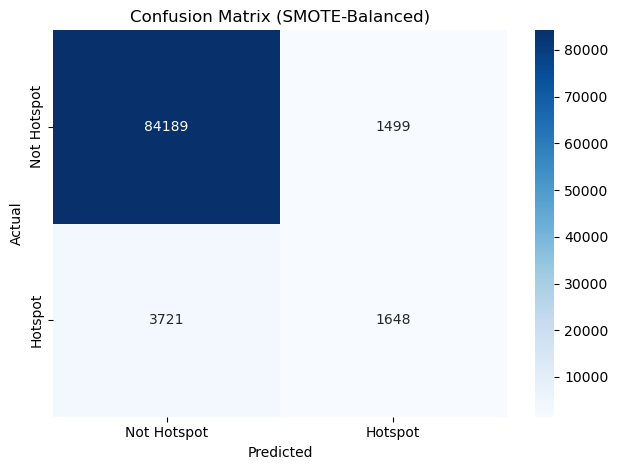

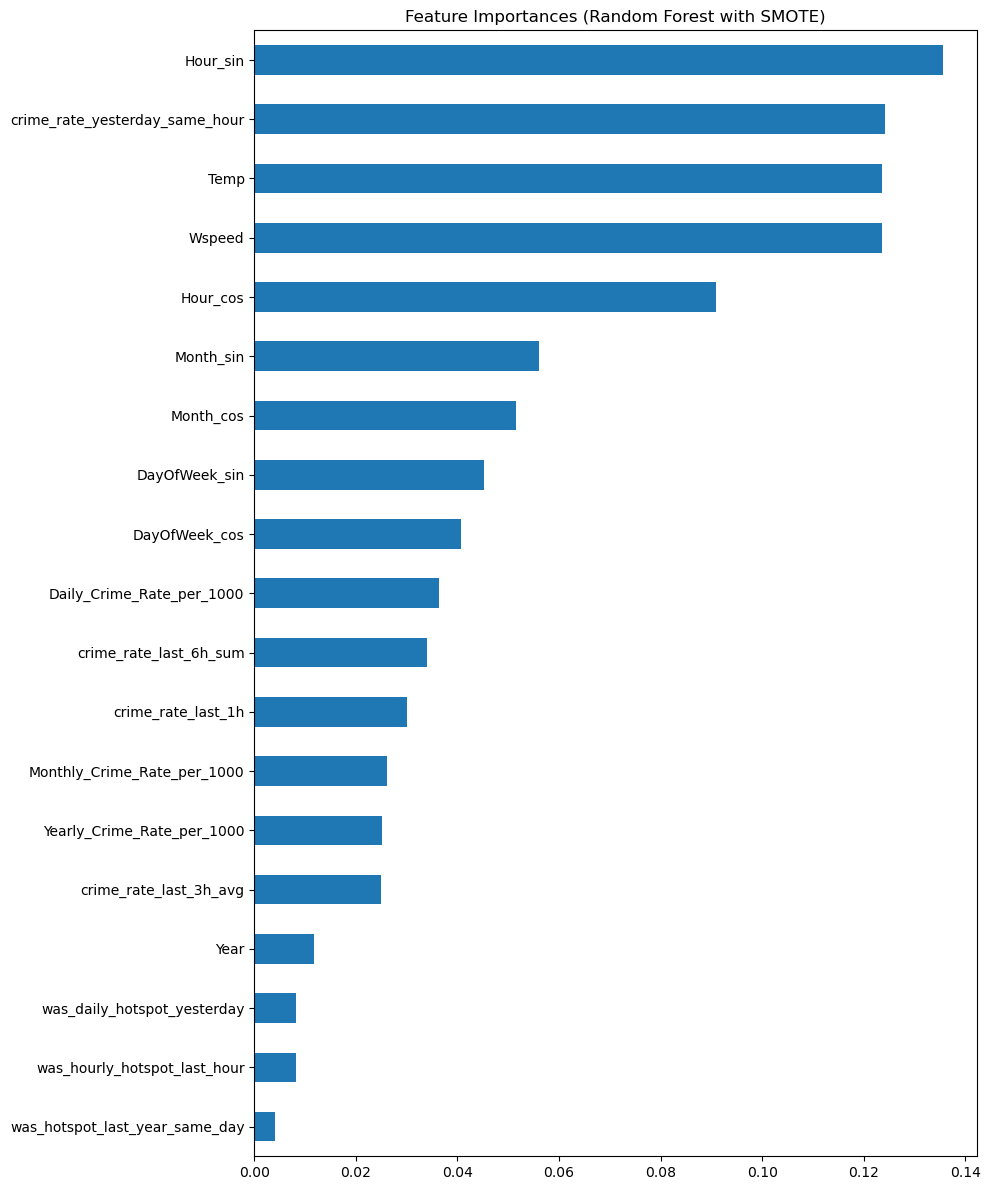

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

df = model_df.copy().dropna()
df = df.sort_values("Datetime_Key")

features_to_exclude = [
    "is_hourly_hotspot", "Hourly_Crime_Rate_per_1000",  # Label leakage
    "Datetime_Key"
]

split_index = int(len(df) * 0.8)
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

y_train = train_df["is_hourly_hotspot"]
y_test = test_df["is_hourly_hotspot"]

X_train = train_df.drop(columns=features_to_exclude).select_dtypes(include=[np.number])
X_test = test_df.drop(columns=features_to_exclude).select_dtypes(include=[np.number])

# Balance Training Set with SMOTE 
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Train Model 
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_bal, y_train_bal)

# ----- Step 5: Predict & Evaluate -----
y_pred = rf.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Hotspot", "Hotspot"], yticklabels=["Not Hotspot", "Hotspot"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (SMOTE-Balanced)")
plt.tight_layout()
plt.show()

# Feature Importances 
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=True)
plt.figure(figsize=(10, 12))
importances.plot(kind="barh")
plt.title("Feature Importances (Random Forest with SMOTE)")
plt.tight_layout()
plt.show()


selected top 10 feature importances

In [125]:
model_df.head()

,Datetime_Key,Hour_sin,DayOfWeek_cos,DayOfWeek_sin,Month_sin,Month_cos,Year,Hour_cos,IsHoliday,IsWeekendorHoliday,Weekend,AREA NAME,Hourly_Crime_Rate_per_1000,Daily_Crime_Rate_per_1000,Monthly_Crime_Rate_per_1000,Yearly_Crime_Rate_per_1000,crime_rate_last_1h,crime_rate_last_3h_avg,crime_rate_last_6h_sum,crime_rate_yesterday_same_hour,was_hourly_hotspot_last_hour,was_daily_hotspot_yesterday,was_hotspot_last_year_same_day,Temp,Wspeed,is_hourly_hotspot
0,2020-01-01 00:00:00,0.000000,-0.222521,0.974928,0.5,0.866025,2020,1.000000,True,True,Weekday,77TH STREET,0.121252,0.72751,11.136501,109.648836,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,20.209677,1.000925,0
169,2020-01-01 01:00:00,0.258819,-0.222521,0.974928,0.5,0.866025,2020,0.965926,True,True,Weekday,77TH STREET,0.009327,0.72751,11.136501,109.648836,0.121252,0.121252,0.727510,0.0,0.0,0.0,0.0,20.512809,1.034353,0
170,2020-01-01 02:00:00,0.500000,-0.222521,0.974928,0.5,0.866025,2020,0.866025,True,True,Weekday,77TH STREET,0.046635,0.72751,11.136501,109.648836,0.009327,0.083943,0.615586,0.0,0.0,0.0,0.0,21.113394,1.348110,0
195,2020-01-01 03:00:00,0.707107,-0.222521,0.974928,0.5,0.866025,2020,0.707107,True,True,Weekday,77TH STREET,0.018654,0.72751,11.136501,109.648836,0.046635,0.046635,0.242503,0.0,0.0,0.0,0.0,20.806047,2.304120,0
199,2020-01-01 04:00:00,0.866025,-0.222521,0.974928,0.5,0.866025,2020,0.500000,True,True,Weekday,77TH STREET,0.046635,0.72751,11.136501,109.648836,0.018654,0.027981,0.223849,0.0,0.0,0.0,0.0,20.618752,1.211153,0


In [ ]:
"""import seaborn as sns
import matplotlib.pyplot as plt

# Columns to analyze (features + target)
correlation_features = [
    "Hourly_Crime_Rate_per_1000", "Daily_Crime_Rate_per_1000", "Monthly_Crime_Rate_per_1000", "Yearly_Crime_Rate_per_1000",
    "crime_rate_last_1h", "crime_rate_last_3h_avg", "crime_rate_last_6h_sum", "crime_rate_yesterday_same_hour",
    "was_hourly_hotspot_last_hour", "was_daily_hotspot_yesterday", "was_hotspot_last_year_same_day",
    "Temp", "Prec", "Wspeed", "WeatherCondition",
    "Hour_sin", "Hour_cos", "DayOfWeek_sin", "DayOfWeek_cos", "Month_sin", "Month_cos",
    "is_hourly_hotspot"  # 🎯 target
]

# Drop rows with missing values
corr_df = crime_df[correlation_features].dropna()

# Compute correlation matrix
corr_matrix = corr_df.corr()

# Plot heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix (including Target)")
plt.tight_layout()
plt.show()"""


c:\Users\jeena\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:16:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.72      0.84     85688
           1       0.17      0.89      0.28      5369

    accuracy                           0.73     91057
   macro avg       0.58      0.81      0.56     91057
weighted avg       0.94      0.73      0.80     91057



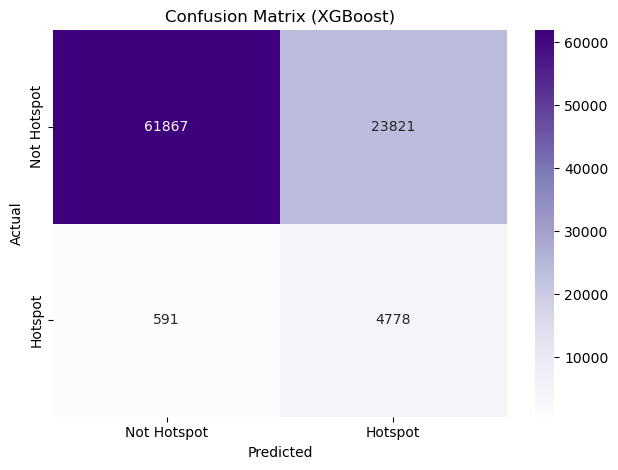

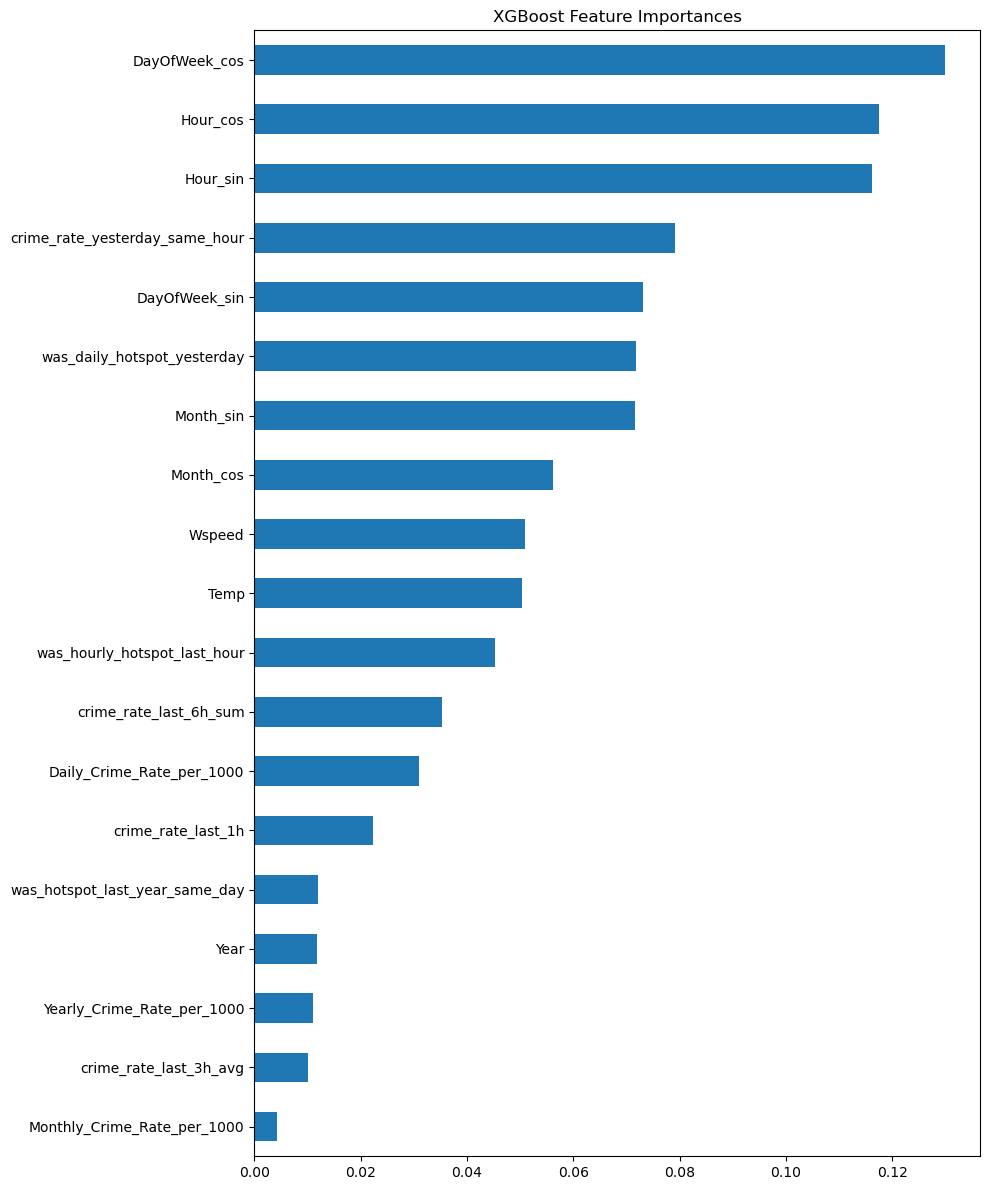

Precision-Recall AUC (XGBoost): 0.5222


In [ ]:
# Feature importance included in graph
# XGBoost Traing
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=10,  # Helps balance class imbalance
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb.fit(X_train_bal, y_train_bal)

# Prediction and Evaluation
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print("\n XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

# Confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt="d", cmap="Purples",
            xticklabels=["Not Hotspot", "Hotspot"], yticklabels=["Not Hotspot", "Hotspot"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (XGBoost)")
plt.tight_layout()
plt.show()

# Feature Importance
importances_xgb = pd.Series(xgb.feature_importances_, index=X_train.columns).sort_values(ascending=True)
plt.figure(figsize=(10, 12))
importances_xgb.plot(kind="barh")
plt.title("XGBoost Feature Importances")
plt.tight_layout()
plt.show()

# Precision-Recall AUC 
precision, recall, _ = precision_recall_curve(y_test, y_proba_xgb)
pr_auc = auc(recall, precision)
print(f"Precision-Recall AUC (XGBoost SMOTE-based): {pr_auc:.4f}")

In [ ]:
# Hyperparameter Tuning

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'scale_pos_weight': [5, 10, 15]  # for class imbalance
}

xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

rs = RandomizedSearchCV(
    xgb_clf,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit on SMOTE-balanced training data
rs.fit(X_train_bal, y_train_bal)

print("Best XGBoost Params:", rs.best_params_)
best_xgb = rs.best_estimator_


Fitting 3 folds for each of 20 candidates, totalling 60 fits


c:\Users\jeena\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:21:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best XGBoost Params: {'subsample': 0.8, 'scale_pos_weight': 5, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.2, 'colsample_bytree': 0.6}


In [ ]:
y_proba_tuned = best_xgb.predict_proba(X_test)[:, 1]


In [ ]:
print("Threshold sweep with tuned model:")
for thresh in np.arange(0.1, 0.91, 0.1):
    preds = (y_proba_tuned > thresh).astype(int)
    f1 = f1_score(y_test, preds)
    rec = recall_score(y_test, preds)
    prec = precision_score(y_test, preds)
    print(f"Threshold = {thresh:.2f} → F1: {f1:.4f}, Recall: {rec:.4f}, Precision: {prec:.4f}")

Threshold sweep with tuned model:
Threshold = 0.10 → F1: 0.1793, Recall: 0.9806, Precision: 0.0987
Threshold = 0.20 → F1: 0.2261, Recall: 0.9516, Precision: 0.1283
Threshold = 0.30 → F1: 0.2681, Recall: 0.9167, Precision: 0.1570
Threshold = 0.40 → F1: 0.3099, Recall: 0.8754, Precision: 0.1882
Threshold = 0.50 → F1: 0.3543, Recall: 0.8301, Precision: 0.2252
Threshold = 0.60 → F1: 0.4017, Recall: 0.7733, Precision: 0.2713
Threshold = 0.70 → F1: 0.4501, Recall: 0.6949, Precision: 0.3328
Threshold = 0.80 → F1: 0.4962, Recall: 0.5942, Precision: 0.4259
Threshold = 0.90 → F1: 0.5074, Recall: 0.4347, Precision: 0.6092


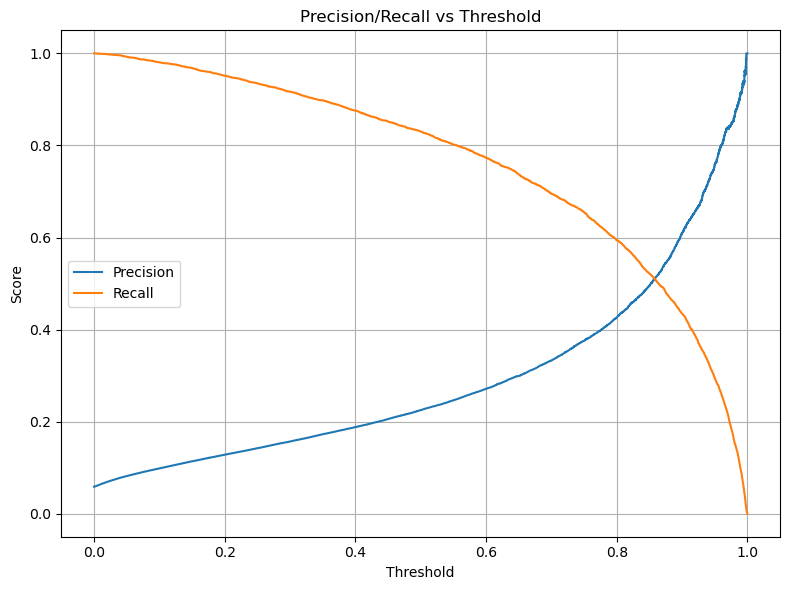

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_tuned)

plt.figure(figsize=(8, 6))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision/Recall vs Threshold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Final Evaluation at threshold 0.80
              precision    recall  f1-score   support

           0       0.97      0.95      0.96     85688
           1       0.43      0.59      0.50      5369

    accuracy                           0.93     91057
   macro avg       0.70      0.77      0.73     91057
weighted avg       0.94      0.93      0.93     91057



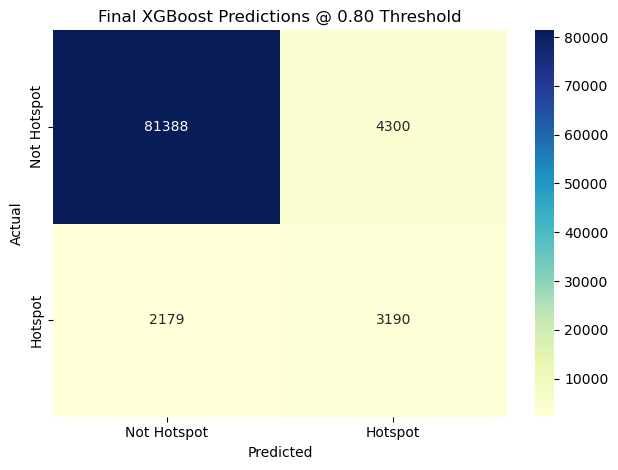

In [ ]:
best_thresh = 0.80
final_preds = (y_proba_tuned > best_thresh).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print("Final Evaluation at threshold 0.80")
print(classification_report(y_test, final_preds))

# Confusion matrix
sns.heatmap(confusion_matrix(y_test, final_preds), annot=True, fmt="d", cmap="YlGnBu",
            xticklabels=["Not Hotspot", "Hotspot"], yticklabels=["Not Hotspot", "Hotspot"])
plt.title("Final XGBoost SMOTE-based Predictions @ 0.80 Threshold")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [ ]:
pip install --upgrade pip

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 1.8/1.8 MB 20.2 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.2
    Uninstalling pip-24.2:
      Successfully uninstalled pip-24.2
Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install tensorflow==2.19.0

   ---------------------------------------- 0.0/376.0 MB ? eta -:--:--
   ---------------------------------------- 4.2/376.0 MB 20.9 MB/s eta 0:00:18
   - -------------------------------------- 10.0/376.0 MB 25.9 MB/s eta 0:00:15
   - -------------------------------------- 15.2/376.0 MB 25.2 MB/s eta 0:00:15
   -- ------------------------------------- 20.2/376.0 MB 25.0 MB/s eta 0:00:15
   -- ------------------------------------- 27.3/376.0 MB 27.0 MB/s eta 0:00:13
   --- ------------------------------------ 34.3/376.0 MB 28.3 MB/s eta 0:00:13
   ---- ----------------------------------- 42.5/376.0 MB 29.7 MB/s eta 0:00:12
   ----- ---------------------------------- 49.5/376.0 MB 30.0 MB/s eta 0:00:11
   ------ --------------------------------- 57.4/376.0 MB 30.7 MB/s eta 0:00:11
   ------ --------------------------------- 64.7/376.0 MB 31.3 MB/s eta 0:00:10
   ------- -------------------------------- 73.1/376.0 MB 31.9 MB/s eta 0:00:10
   -------- ------------------------------- 81.0/3

In [ ]:
# Autoencoders on Unlabelled data
!pip install Keras
from keras.models import Model
# !pip install tensorflow
from keras.layers import Input, Dense
from keras import regularizers
from sklearn.preprocessing import MinMaxScaler


# Prepare feature set
ae_df = crime_df.copy()
features = ae_df.drop(columns=["Datetime_Key", "AREA NAME", "is_hourly_hotspot"])
features = features.select_dtypes(include=[np.number])



In [ ]:
#Making sure there are no nan values
imputer = SimpleImputer(strategy="mean")
features = imputer.fit_transform(features)
print(np.isnan(features).sum())  # Should be 0
print(np.isinf(features).sum())  # Should be 0
# Normalizing
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(features)

0
0


In [ ]:
# Building autoencoders
input_dim = X_scaled.shape[1]
encoding_dim = 16  # Compressed layer

input_layer = Input(shape=(input_dim,))
encoded = Dense(32, activation='relu')(input_layer)
encoded = Dense(encoding_dim, activation='relu', activity_regularizer=regularizers.l1(1e-5))(encoded)

decoded = Dense(32, activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='mse')



In [ ]:
# Train only on non-hotspot rows
X_train = X_scaled[ae_df["is_hourly_hotspot"] == 0]
print(np.isnan(X_train).sum())  # Should be 0
print(np.isinf(X_train).sum())  # Should be 0



0
0


In [81]:
autoencoder.fit(X_train, X_train, epochs=20, batch_size=512, validation_split=0.1, shuffle=True, verbose=1)


Epoch 1/20
2824/2824 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 0.0611 - val_loss: 0.0324
Epoch 2/20
2824/2824 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0346 - val_loss: 0.0309
Epoch 3/20
2824/2824 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0331 - val_loss: 0.0305
Epoch 4/20
2824/2824 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0325 - val_loss: 0.0305
Epoch 5/20
2824/2824 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0313 - val_loss: 0.0295
Epoch 6/20
2824/2824 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.0303 - val_loss: 0.0285
Epoch 7/20
2824/2824 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0296 - val_loss: 0.0270
Epoch 8/20
2824/2824 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 0.0291 - val_loss: 0.0264
Epoch 9/20
2824/2824 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0287 - val_loss: 0.0262
Epoch 10/20
2824/2824 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 0.0284 - val_loss: 0.0255
Epoch 11/20
2824/2824 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0283 - val_loss: 0.0254
Epoch 12/20
2824/2824 ━━━━━━

In [ ]:
# visualize epoch values

In [115]:
# Getting reconstruction error for all data
X_pred = autoencoder.predict(X_scaled)
mse = np.mean(np.power(X_scaled - X_pred, 2), axis=1)
ae_df["recon_error"] = mse

# Defining anomaly threshold  
threshold = np.percentile(mse[ae_df["is_hourly_hotspot"] == 0], 80)

# Predicting based on error
ae_df["ae_hotspot"] = (mse > threshold).astype(int)





64143/64143 ━━━━━━━━━━━━━━━━━━━━ 56s 871us/step


Classification Report (Autoencoder Only):
              precision    recall  f1-score   support

           0       0.90      0.80      0.85   1606127
           1       0.48      0.67      0.56    446437

    accuracy                           0.77   2052564
   macro avg       0.69      0.74      0.70   2052564
weighted avg       0.81      0.77      0.78   2052564



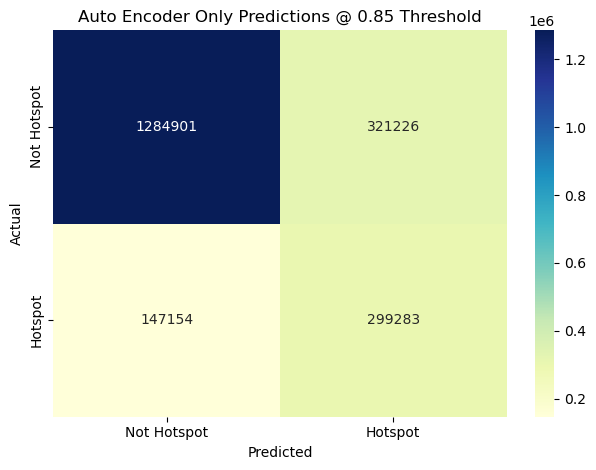

In [ ]:
print("Classification Report (Autoencoder Only):")
print(classification_report(ae_df["is_hourly_hotspot"], ae_df["ae_hotspot"]))

# Confusion matrix - just for visualization
sns.heatmap(confusion_matrix(ae_df["is_hourly_hotspot"],  ae_df["ae_hotspot"]), annot=True, fmt="d", cmap="YlGnBu",
            xticklabels=["Not Hotspot", "Hotspot"], yticklabels=["Not Hotspot", "Hotspot"])
plt.title("Auto Encoder Only Predictions @ 0.85 Threshold")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [117]:
# Extracting encoder model
encoder = Model(inputs=input_layer, outputs=encoded)
X_encoded = encoder.predict(X_scaled)

# Using encoded + original label
encoded_df = pd.DataFrame(X_encoded)
encoded_df["is_hourly_hotspot"] = ae_df["is_hourly_hotspot"].values



64143/64143 ━━━━━━━━━━━━━━━━━━━━ 52s 813us/step


In [118]:
# Training/testing split without SMOTE
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

X_train_enc, X_test_enc, y_train_enc, y_test_enc = train_test_split(
    encoded_df.drop(columns=["is_hourly_hotspot"]),
    encoded_df["is_hourly_hotspot"],
    test_size=0.2,
    random_state=42,
    stratify=encoded_df["is_hourly_hotspot"]
)

c:\Users\jeena\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:36:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification Report (Autoencoder + XGBoost):
              precision    recall  f1-score   support

           0       0.98      0.05      0.09    321226
           1       0.23      1.00      0.37     89287

    accuracy                           0.25    410513
   macro avg       0.60      0.52      0.23    410513
weighted avg       0.82      0.25      0.15    410513



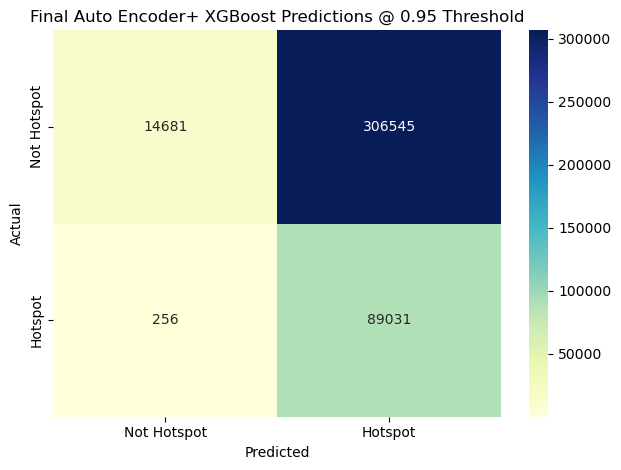

In [ ]:
# Training XGBoost on encoded features
xgb = XGBClassifier(scale_pos_weight=10, use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train_enc, y_train_enc)

# Predict & Evaluate
y_pred_enc = xgb.predict(X_test_enc)
print("Classification Report (Autoencoder + XGBoost):")
print(classification_report(y_test_enc, y_pred_enc))

# Confusion matrix
sns.heatmap(confusion_matrix(y_test_enc, y_pred_enc), annot=True, fmt="d", cmap="YlGnBu",
            xticklabels=["Not Hotspot", "Hotspot"], yticklabels=["Not Hotspot", "Hotspot"])
plt.title("Final Auto Encoder+ XGBoost Predictions @ 0.80 Threshold")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()
